安裝環境

In [2]:
import importlib.util
import subprocess
import sys

# 在子程序檢查，避免安裝前先載入目前 kernel 的動態函式庫
check_code = """
import pygmt, pandas
import shutil
from pygmt.clib import Session
assert pygmt.__version__.lstrip('v').startswith('0.17.')
assert shutil.which('gs')
with Session() as session:
    assert session.info['version'].startswith('6.5.')
"""
try:
    ENV_READY = subprocess.run(
        [sys.executable, "-c", check_code], capture_output=True, timeout=30
    ).returncode == 0
except subprocess.TimeoutExpired:
    ENV_READY = False

IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
if ENV_READY:
    print("環境已可用，跳過安裝。")
elif IN_COLAB:
    print("步驟 1/2：安裝 Conda（約 1 分鐘）。完成後 Colab 會自動重啟執行環境，等重新連線再執行下一格。", flush=True)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "condacolab==0.1.13"])
    import condacolab
    condacolab.install()
else:
    print("本機模式：使用目前 Python 環境。")

步驟 1/2：安裝 Conda（約 1 分鐘）。完成後 Colab 會自動重啟執行環境，等重新連線再執行下一格。

📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [3]:
import importlib.util
import subprocess
import sys

# 在子程序檢查，避免安裝前先載入目前 kernel 的動態函式庫
check_code = """
import pygmt, pandas
import shutil
from pygmt.clib import Session
assert pygmt.__version__.lstrip('v').startswith('0.17.')
assert shutil.which('gs')
with Session() as session:
    assert session.info['version'].startswith('6.5.')
"""
try:
    ENV_READY = subprocess.run(
        [sys.executable, "-c", check_code], capture_output=True, timeout=30
    ).returncode == 0
except subprocess.TimeoutExpired:
    ENV_READY = False

IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
if ENV_READY:
    print("環境已可用，跳過安裝。")
elif IN_COLAB:
    print("步驟 2/2：安裝 PyGMT 與相依套件（約 2–4 分鐘），下方會逐行顯示進度。", flush=True)
    command = ["mamba", "install", "-y", "-c", "conda-forge", "pygmt=0.17", "gmt=6.5", "ghostscript=10.04", "pandas"]
    with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1) as process:
        for line in process.stdout:
            print(line.rstrip(), flush=True)
    if process.returncode != 0:
        raise RuntimeError(f"安裝失敗（exit {process.returncode}），請重新執行本格或重啟執行環境。")
    print("安裝完成，可以往下執行。")
else:
    print("跳過 Colab 安裝。")


步驟 2/2：安裝 PyGMT 與相依套件（約 2–4 分鐘），下方會逐行顯示進度。

Pinned packages:

  - python=3.13

Pinned packages:

  - python_abi[version="=3.13",build="*cp313*"]

Pinned packages:

  - cuda-version*.*

Pinned packages:

  - python=3.13


Transaction

  Prefix: /usr/local

  Updating specs:

   - pygmt=0.17
   - gmt=6.5
   - ghostscript=10.4
   - pandas


  Package                    Version  Build                 Channel           Size
────────────────────────────────────────────────────────────────────────────────────
  Install:
────────────────────────────────────────────────────────────────────────────────────

  + blosc                     1.21.6  he440d0b_1            conda-forge       48kB
  + curl                      8.20.0  hcf29cc6_0            conda-forge      191kB
  + dcw-gmt                    2.2.0  ha770c72_0            conda-forge       22MB
  + fftw                      3.3.11  nompi_h3b011a4_100    conda-forge        2MB
  + freexl                     2.0.0  h1f12c17_3            con

clone

In [1]:
import os

# Clone the fork of the repository
repo_name = "pygmt-map-lab"
if not os.path.exists(repo_name):
    !git clone https://github.com/u11410024-pog/pygmt-map-lab

else:
    print(f"Repository '{repo_name}' already exists. Skipping clone.")

Cloning into 'pygmt-map-lab'...
remote: Enumerating objects: 552, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 552 (delta 6), reused 4 (delta 4), pack-reused 545 (from 1)
Receiving objects: 100% (552/552), 16.07 MiB | 9.04 MiB/s, done.
Resolving deltas: 100% (349/349), done.


範例test

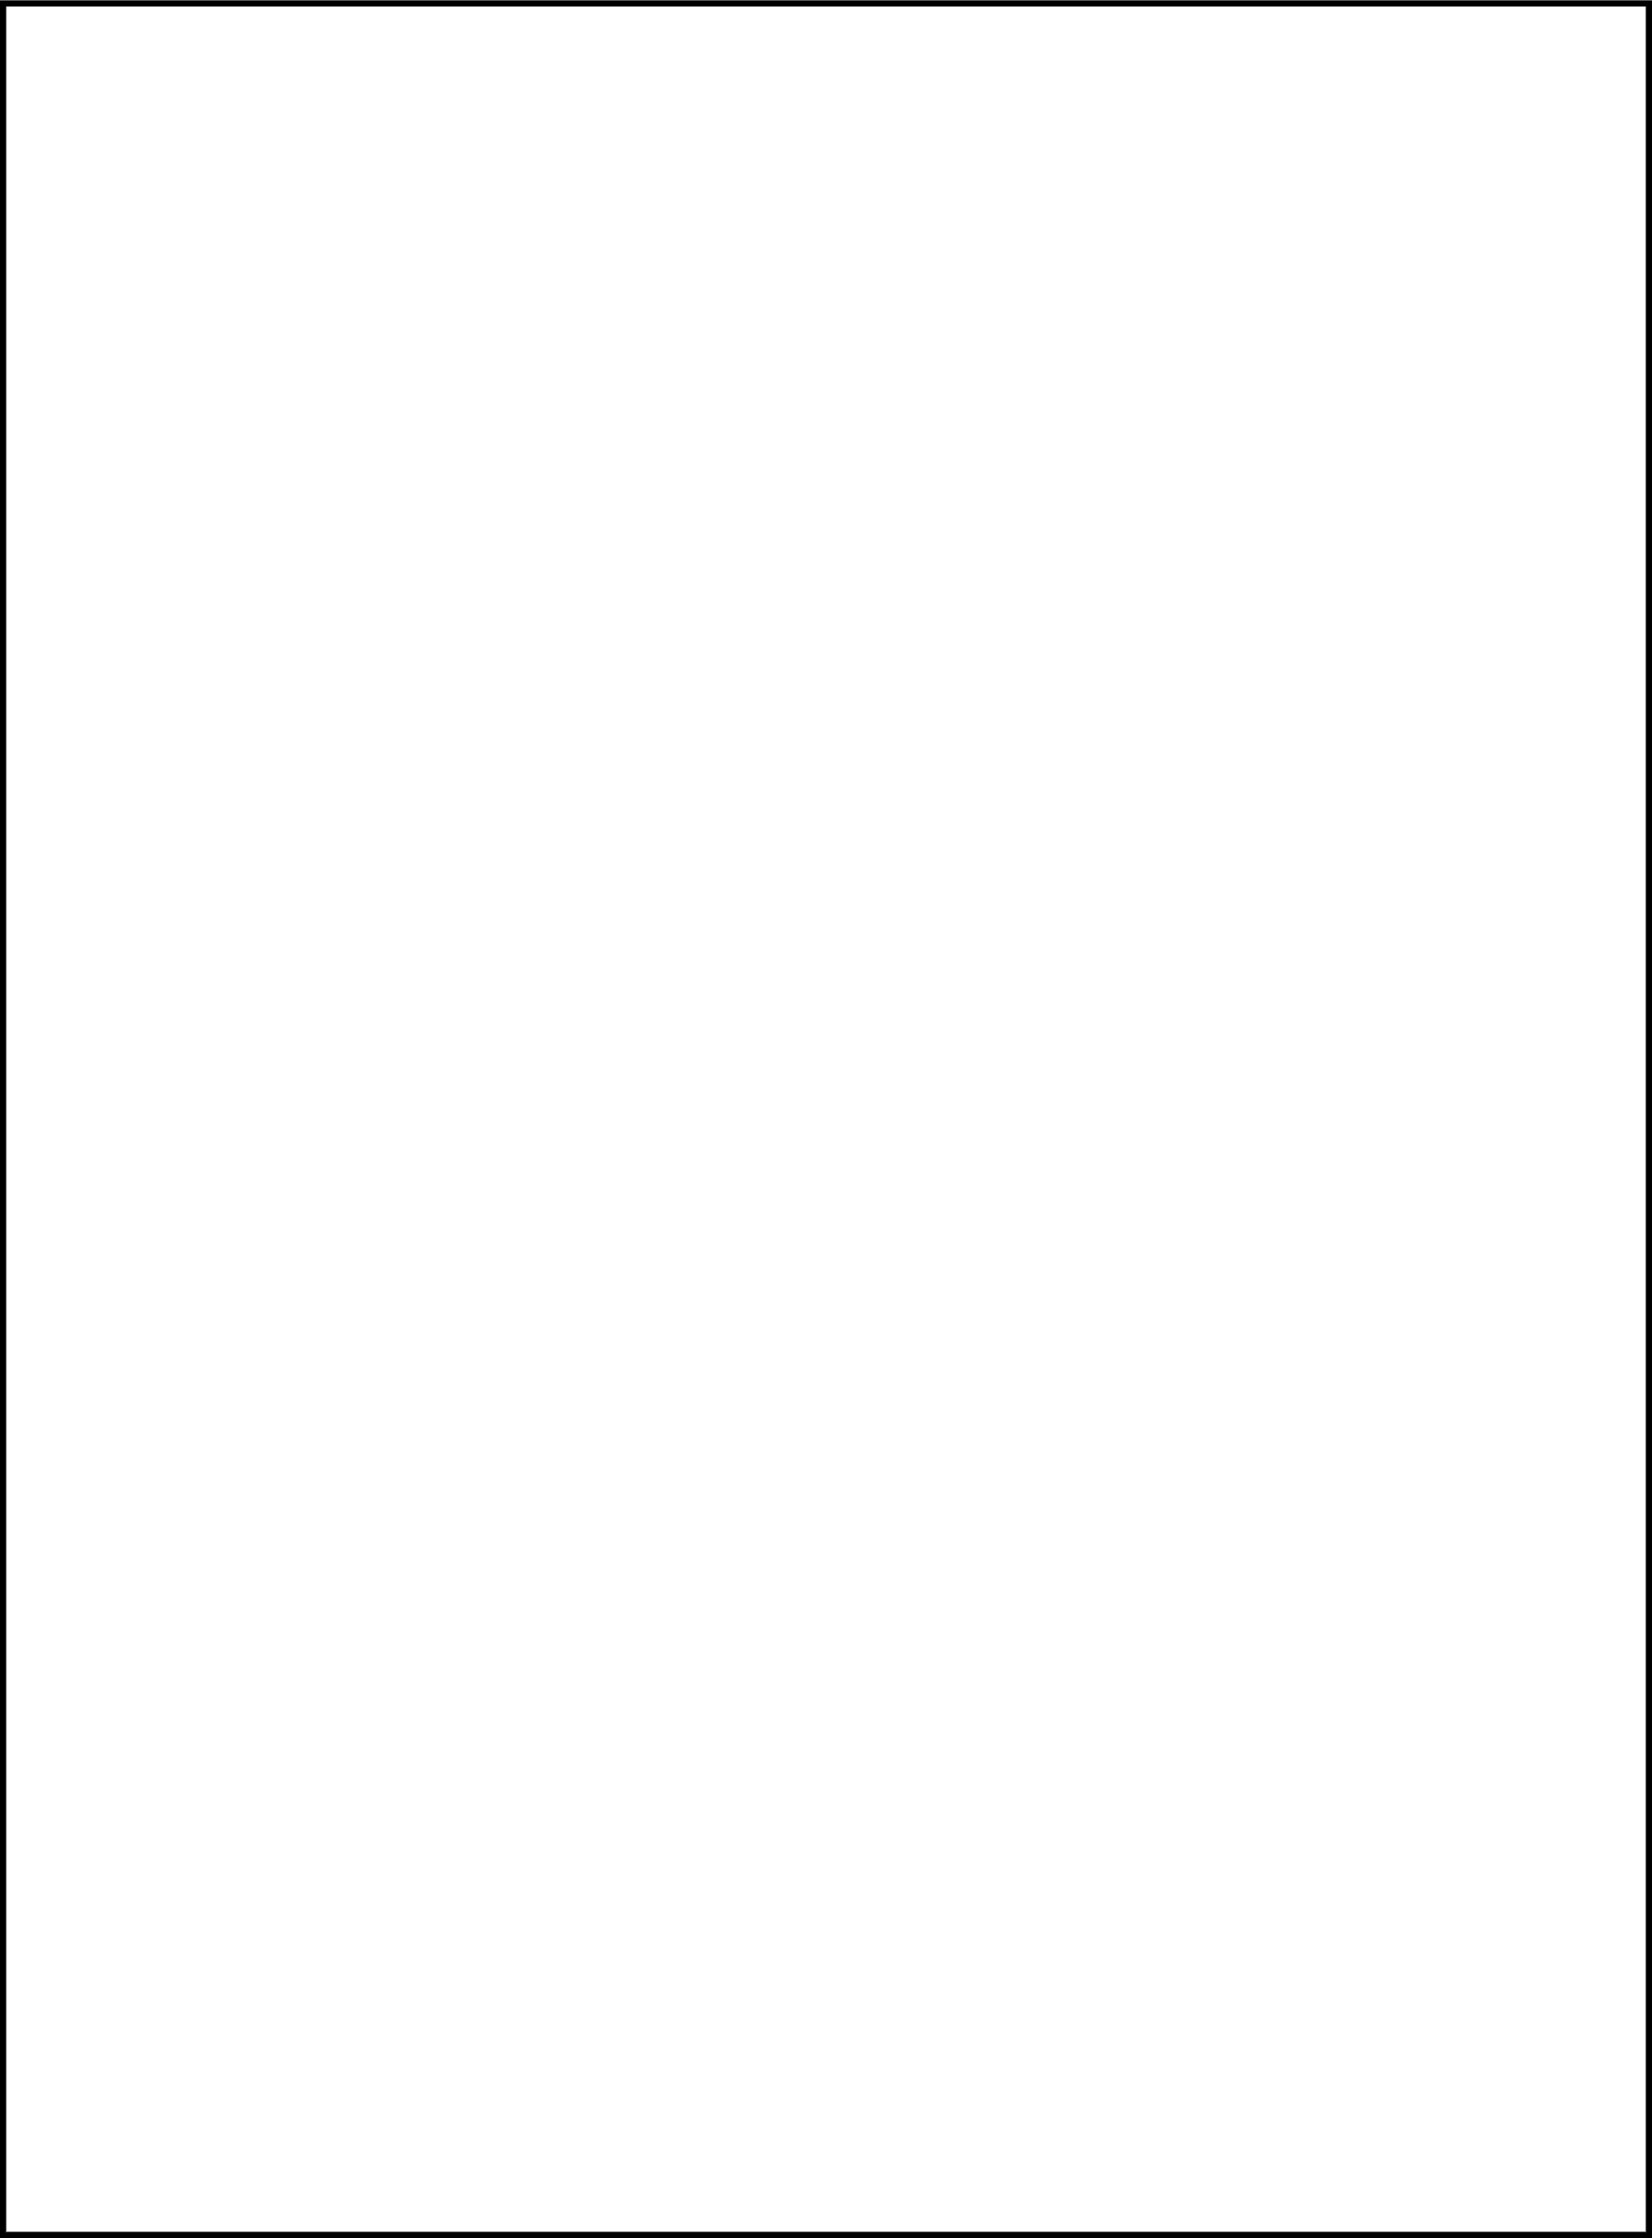

In [ ]:
import pygmt

fig = pygmt.Figure()
fig.basemap(region=[119, 123, 21, 26], projection="M15c", frame="0")

# 1. 加上經緯度數字與刻度（a：標示數字；f：刻度）
# fig.basemap(frame="af")

# 2. 填上陸地與海洋顏色
# fig.coast(land="gray90", water="lightblue", resolution="h")

# 3. 加上海岸線
# fig.coast(shorelines="0.6p,gray30", resolution="h")

# 4. 加上每 1 度的經緯格線，並重畫刻度（g：格線）
# fig.basemap(frame="a1f0.5g1")

# 5. 加上標題
# fig.basemap(frame="+tTaiwan: coastlines")

# 6. 加上 50 km 比例尺
# fig.basemap(map_scale="jBR+c24+w50k+o0.5c/0.5c+f+lkm")

fig.show()
# 圖片顯示後，可按右鍵另存圖片。


USGS 2000-01-01 起 M >= 5.5：13190 筆
火山：1608 座
熱點：55 個
saved global_overview.png | 白三角＝全新世火山；黃星＝熱點
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
圖片已成功儲存至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/global_overview.png


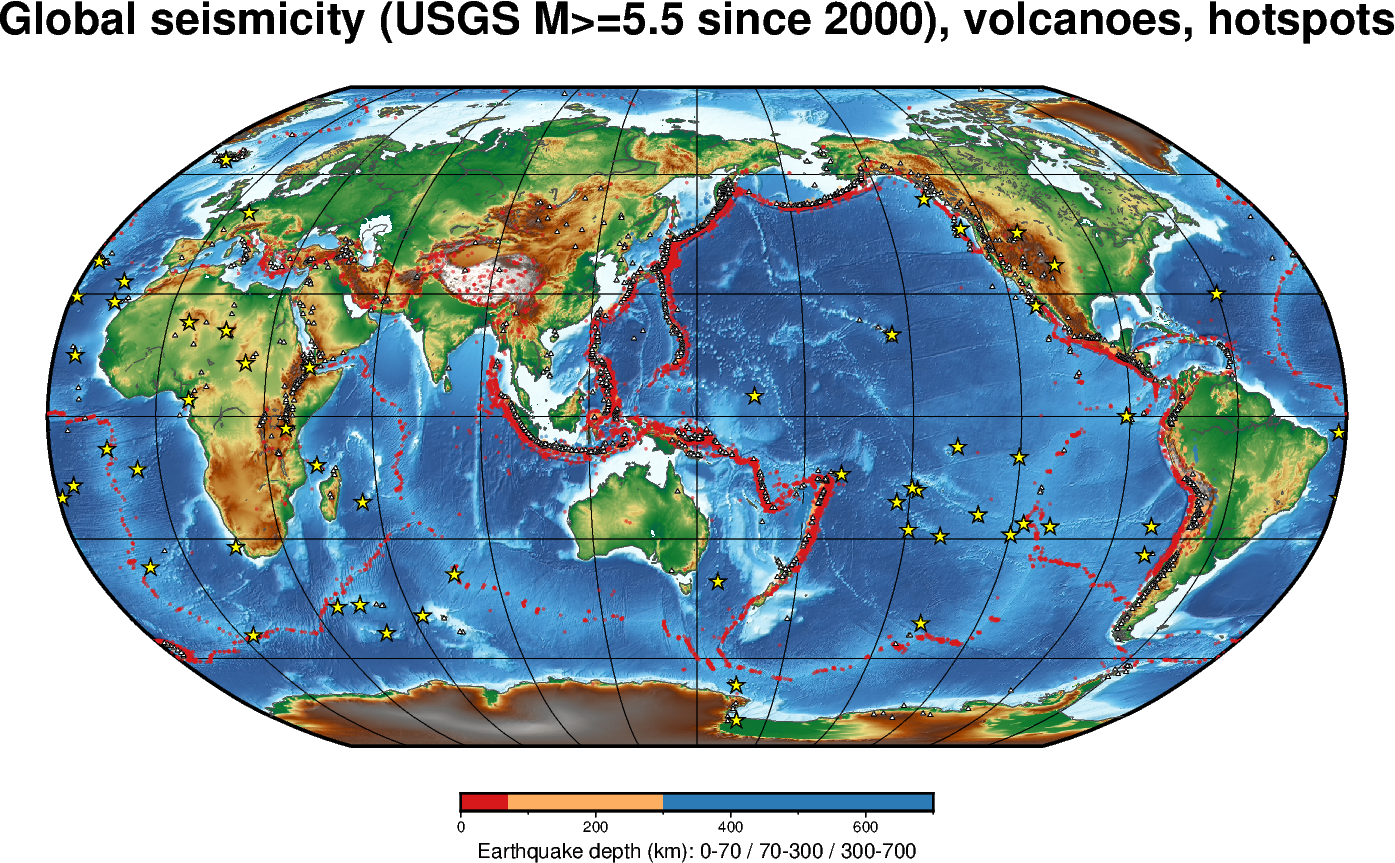

In [ ]:
"""全球總覽：地形底圖 + USGS 地震（三段深度）+ 全新世火山 + 熱點。

輸出：global_overview.png
資料：USGS 地震目錄 API、NOAA NCEI 火山位置 API（源自 Smithsonian GVP）、
      GMT 範例檔 @hotspots.txt（Müller, Royer & Lawver 1993）、GMT 全球地形 10 角分。
需要：pygmt 0.17（含 pandas、numpy）。執行約 1 分鐘，需連網。
"""
import json
import urllib.request

import pandas as pd
import pygmt

# ==== 可以改的參數 ====
START = "2000-01-01"          # 地震起始日
MINMAG = 5.5                  # 最低規模；全球 M >= 5.5 自 2000 年約 13,000 筆
OUT = "global_overview.png"
# ======================

# 1. 地震：先查筆數，超過 USGS 單次上限 20,000 就提高規模
base = "https://earthquake.usgs.gov/fdsnws/event/1/"
minmag = MINMAG
while True:
    query = f"starttime={START}&minmagnitude={minmag}"
    count = int(urllib.request.urlopen(base + "count?" + query).read())
    if count <= 20000:
        break
    minmag += 0.5
quakes = pd.read_csv(base + "query?format=csv&" + query).dropna(subset=["longitude", "latitude", "depth", "mag"])
quakes = quakes.sort_values("depth", ascending=False)  # 深的先畫，淺的疊在上面
print(f"USGS {START} 起 M >= {minmag}：{len(quakes)} 筆")

# 2. 火山：NCEI 全新世火山清單，每頁 200 筆
rows, page = [], 1
while True:
    url = f"https://www.ngdc.noaa.gov/hazel/hazard-service/api/v1/volcanolocs?itemsPerPage=200&page={page}"
    with urllib.request.urlopen(url) as response:
        data = json.load(response)
    rows += data["items"]
    if page >= data["totalPages"]:
        break
    page += 1
volcanoes = pd.DataFrame(rows).dropna(subset=["latitude", "longitude"])
print(f"火山：{len(volcanoes)} 座")

# 3. 熱點：GMT 範例檔，第 1、2 欄是經度、緯度
hotspots = pd.read_csv(pygmt.which("@hotspots.txt", download="c"), sep=r"\s+",
                       comment="#", header=None, usecols=[0, 1], names=["lon", "lat"])
print(f"熱點：{len(hotspots)} 個")

# 4. 畫圖
fig = pygmt.Figure()
fig.grdimage(grid="@earth_relief_10m", region="d", projection="N150/22c", cmap="geo", shading="+a-45+nt0.4",
             frame=[f"+tGlobal seismicity (USGS M>={minmag} since {START[:4]}), volcanoes, hotspots", "g30"])
fig.coast(shorelines="0.15p,gray30")
pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")  # 淺、中、深三段
fig.plot(x=quakes.longitude, y=quakes.latitude, style="c0.05c", fill=quakes.depth, cmap=True, transparency=40)
fig.plot(x=volcanoes.longitude, y=volcanoes.latitude, style="t0.1c", fill="white", pen="0.15p,black")
fig.plot(x=hotspots.lon, y=hotspots.lat, style="a0.3c", fill="yellow", pen="0.4p,black")
fig.colorbar(position="JBC+w8c/0.3c+h+o0c/0.8c", frame=["a0", "+lEarthquake depth (km): 0-70 / 70-300 / 300-700"])
fig.savefig(OUT, dpi=150)
print("saved", OUT, "| 白三角＝全新世火山；黃星＝熱點")
import os
from google.colab import drive
from IPython.display import Image

# 1. 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# 2. 設定儲存至您指定的資料夾路徑
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)
out_file = os.path.join(folder_path, "global_overview.png")

# 3. 儲存圖片至雲端硬碟並在畫面上顯示
fig.savefig(out_file, dpi=150)
print("圖片已成功儲存至雲端硬碟：", out_file)

Image(out_file)

In [ ]:
"""八個交界帶的平面圖，一次畫完，同一套設定方便對照：
地形底圖、USGS 地震三段深度、比例尺、右上角地球儀標出位置。

輸出：map_views_eight_regions.png
資料：USGS 地震目錄 API、GMT 全球地形 2 角分。
需要：pygmt 0.17（含 pandas、numpy）。執行約 3–5 分鐘，需連網。
"""
import math
import urllib.request

import pandas as pd
import pygmt

# ==== 改這裡：名稱與範圍（西、東、南、北） ====
REGIONS = [
    ("Japan-Kuril", [138, 155, 33, 48]),
    ("Tonga-Kermadec", [175, 190, -38, -15]),    # 跨換日線，經度直接用到 190
    ("Peru-Chile", [-80, -65, -35, -15]),
    ("Cascadia", [-130, -118, 40, 52]),
    ("East African Rift", [28, 42, -12, 12]),
    ("East Pacific Rise", [-115, -95, -20, 5]),
    ("San Andreas", [-125, -114, 32, 40]),
    ("Himalaya", [75, 95, 22, 38]),
]
START = "2010-01-01"
OUT = "map_views_eight_regions.png"
# ==========================================
MAX_W, MAX_H = 8.0, 7.5   # 每格最大寬高（cm）
base = "https://earthquake.usgs.gov/fdsnws/event/1/"


def fetch(region):
    """從 M >= 4.5 開始，超過 20,000 筆就提高規模"""
    for minmag in (4.5, 5.0, 5.5, 6.0):
        q = (f"starttime={START}&minmagnitude={minmag}"
             f"&minlongitude={region[0]}&maxlongitude={region[1]}&minlatitude={region[2]}&maxlatitude={region[3]}")
        if int(urllib.request.urlopen(base + "count?" + q).read()) <= 20000:
            df = pd.read_csv(base + "query?format=csv&" + q).dropna(subset=["longitude", "latitude", "depth", "mag"])
            return df, minmag
    raise RuntimeError("too many events")


def mag_size(m):
    return 0.06 * 2 ** (m - 4.5)


def panel_size(region):
    """依麥卡托投影的長寬比決定格子大小"""
    y0 = math.log(math.tan(math.pi / 4 + math.radians(region[2]) / 2))
    y1 = math.log(math.tan(math.pi / 4 + math.radians(region[3]) / 2))
    ratio = (y1 - y0) / math.radians(region[1] - region[0])
    w = MAX_W
    h = w * ratio
    if h > MAX_H:
        h, w = MAX_H, MAX_H / ratio
    return w, h


fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY="7p", FONT_TITLE="10p", MAP_FRAME_TYPE="plain")
cols = 4
for i, (name, region) in enumerate(REGIONS):
    quakes, minmag = fetch(region)
    quakes = quakes.sort_values("depth", ascending=False)  # 深的先畫
    grid = pygmt.datasets.load_earth_relief(resolution="02m", region=region)
    w, h = panel_size(region)
    col, row = i % cols, i // cols
    fig.shift_origin(xshift=f"f{1 + col * (MAX_W + 1.5)}c", yshift=f"f{3 + (1 - row) * (MAX_H + 2.5)}c")

    fig.grdimage(grid=grid, region=region, projection=f"M{w}c", cmap="geo", shading="+a-45+nt0.5",
                 frame=[f"WSne+t{name}", "a5f1"])
    fig.coast(shorelines="0.3p,gray20", resolution="i")
    pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")
    fig.plot(x=quakes.longitude, y=quakes.latitude, size=quakes.mag.apply(mag_size),
             fill=quakes.depth, cmap=True, style="c", pen="0.15p,black", transparency=30)
    fig.basemap(map_scale=f"jBL+c{(region[2] + region[3]) / 2}+w500k+o0.3c/0.3c+f+lkm")
    fig.text(text=f"USGS M>={minmag} since {START[:4]}: {len(quakes)} events", position="TL",
             offset="0.15c/-0.15c", font="6p", fill="white@30")
    with fig.inset(position="jTR+w2c+o0.1c"):
        lon_c, lat_c = (region[0] + region[1]) / 2, (region[2] + region[3]) / 2
        fig.coast(region="g", projection=f"G{lon_c}/{lat_c}/2c", land="gray70", water="white", frame="g")
        fig.plot(x=[region[0], region[1], region[1], region[0]], y=[region[2], region[2], region[3], region[3]],
                 close=True, pen="1p,red")
    print(name, "M>=", minmag, len(quakes))

# 共用色條：整張圖正下方置中（4 欄總寬約 38 cm；面板從 y=3c 起，底下留給色條）
fig.shift_origin(xshift="f0c", yshift="f0c")
fig.colorbar(cmap=True, position="x15c/1.3c+w8c/0.35c+h", frame=["a0", "+lDepth class (km): 0-70 / 70-300 / 300-700"])
fig.savefig(OUT, dpi=150)
print("saved", OUT)
import os
from google.colab import drive
from IPython.display import Image

# 1. 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# 2. 設定儲存至您指定的資料夾路徑
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)
out_file = os.path.join(folder_path, "global_overview2.png")

# 3. 儲存圖片至雲端硬碟並在畫面上顯示
fig.savefig(out_file, dpi=150)
print("圖片已成功儲存至雲端硬碟：", out_file)

Image(out_file)

Output hidden; open in https://colab.research.google.com to view.

USGS 1990-01-01 起 M >= 5.0：3926 筆，走廊內 535 筆
下載 TX2019slab ...


/usr/local/lib/python3.13/site-packages/pygmt/clib/session.py:1647: RuntimeWarning: Grid may have irregular spacing in the 'x' dimension, but GMT only supports regular spacing. Calculated regular spacing 9.96107370870245 is assumed in the 'x' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


saved tomography_section.png | 讀圖：藍色帶是否傾斜？地震是否貼著它？
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
圖片已成功儲存至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/global_overview4.png


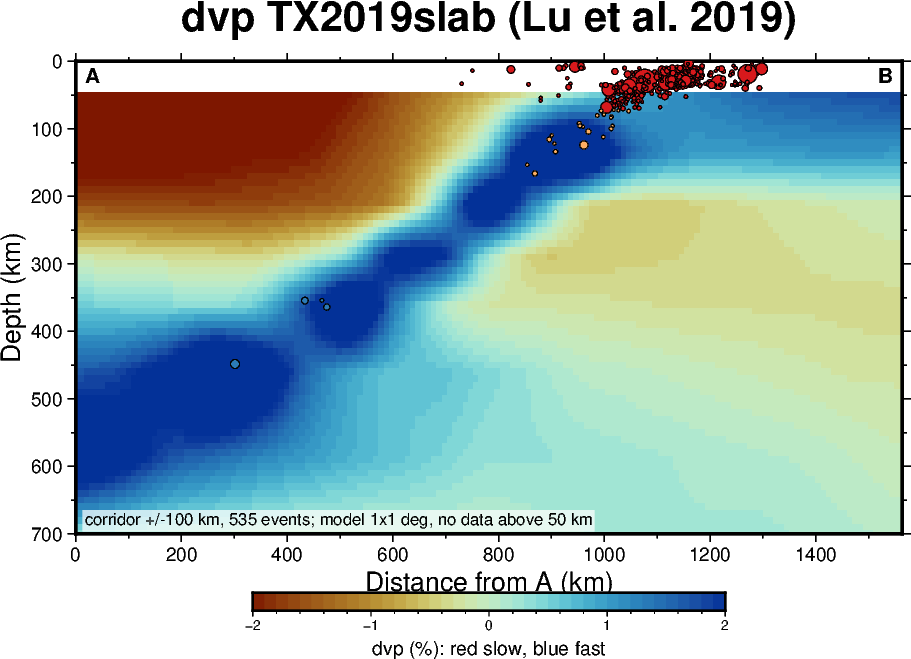

In [ ]:
"""速度剖面：同一條 A–B 底下鋪 TX2019slab（Lu et al. 2019）的 P 波速度異常，地震疊在上面。
藍色快，通常是冷的板片；紅色慢，通常是熱的地函。模型 1°×1°、22 層，50 km 以下才有值。

輸出：tomography_section.png
資料：EarthScope EMC TX2019slab（6.7 MB，首次執行下載）、USGS 地震目錄 API。
需要：pygmt 0.17（含 pandas、numpy、xarray）。三維模型由 GMT 自己讀，不需要 netCDF4 或 SciPy。
"""
import os
import re
import urllib.request

import numpy as np
import pandas as pd
import pygmt
import xarray as xr
from pygmt.clib import Session

# ==== 改這裡（和 02_region_map_section.py 用同一組參數，兩張圖才對得上）====
REGION = [128, 150, 30, 46]
START, MINMAG = "1990-01-01", 5.0
A, B = (130, 38.5), (148, 38.5)
HALF_WIDTH_KM = 100
DEPTH_MAX = 700
VAR = "dvp"                        # 或 "dvs"
MODEL = "TX2019slab.nc"
MODEL_URL = "https://data.earthscope.org/archive/seismology/products/emc/netcdf/TX2019slab_percent.r0.0-n4c.nc"
OUT = "tomography_section.png"
# ==========================================================================

# 1. 地震與 A–B 走廊（與 02 相同）
base = "https://earthquake.usgs.gov/fdsnws/event/1/"
query = (f"starttime={START}&minmagnitude={MINMAG}"
         f"&minlongitude={REGION[0]}&maxlongitude={REGION[1]}&minlatitude={REGION[2]}&maxlatitude={REGION[3]}")
assert int(urllib.request.urlopen(base + "count?" + query).read()) <= 20000, "超過 USGS 上限，請提高 MINMAG"
quakes = pd.read_csv(base + "query?format=csv&" + query).dropna(subset=["longitude", "latitude", "depth", "mag"])
selected = pygmt.project(data=quakes[["longitude", "latitude", "depth", "mag"]],
                         center=list(A), endpoint=list(B), unit=True, length="w",
                         width=[-HALF_WIDTH_KM, HALF_WIDTH_KM], convention="xypqz")
selected.columns = ["longitude", "latitude", "distance", "offset", "depth", "mag"]
track = pygmt.project(center=list(A), endpoint=list(B), generate=10, unit=True)
track.columns = ["lon", "lat", "distance"]
length_km = float(track.distance.iloc[-1])
print(f"USGS {START} 起 M >= {MINMAG}：{len(quakes)} 筆，走廊內 {len(selected)} 筆")


def mag_size(m):
    return min(0.05 * 2 ** (m - 5), 0.4)


# 2. 下載模型（只下載一次）
if not os.path.exists(MODEL):
    print("下載 TX2019slab ...")
    urllib.request.urlretrieve(MODEL_URL, MODEL)

# 3. 用 GMT 讀三維模型：grdinterpolate -T 抽出一層，再用 grdtrack 沿 A–B 取樣，逐層做完就是剖面
info = pygmt.grdinfo(f"{MODEL}?{VAR}")
levels = [float(v) for v in re.search(r"z_levels: (.*)", info).group(1).split(",")]
levels = [level for level in levels if level <= DEPTH_MAX]


def sample_level(level):
    with Session() as lib:
        with lib.virtualfile_out(kind="grid") as vout:
            lib.call_module("grdinterpolate", [f"{MODEL}?{VAR}", f"-T{level}", f"-G{vout}"])
            layer = lib.virtualfile_to_raster(vfname=vout, kind="grid")
    return pygmt.grdtrack(points=track[["lon", "lat"]], grid=layer, newcolname="value").value.to_numpy()


matrix = np.array([sample_level(level) for level in levels])  # 深度層 x 點
levels = np.array(levels)

# 4. 深度再內插成每 10 km；模型最淺一層 50 km，以上留白
depths = np.arange(0, DEPTH_MAX + 10, 10)
slice_values = np.full((len(depths), matrix.shape[1]), np.nan)
for j in range(matrix.shape[1]):
    slice_values[:, j] = np.interp(depths, levels, matrix[:, j], left=np.nan, right=np.nan)
tomo = xr.DataArray(slice_values, coords={"y": depths, "x": track.distance.values}, dims=("y", "x"))

# 5. 速度剖面 + 地震
fig = pygmt.Figure()
pygmt.makecpt(cmap="roma", series=[-2, 2, 0.1])  # 紅慢、藍快
fig.grdimage(grid=tomo, region=[0, length_km, 0, DEPTH_MAX], projection="X14c/-8c", cmap=True, nan_transparent=True,
             frame=[f"WSne+t{VAR} TX2019slab (Lu et al. 2019)", "xa200f100+lDistance from A (km)", "ya100f50+lDepth (km)"])
fig.colorbar(position="JBC+w8c/0.3c+h+o0c/1c", frame=["a1", f"+l{VAR} (%): red slow, blue fast"])
pygmt.makecpt(cmap="#d7191c,#fdae61,#2c7bb6", series="0,70,300,700")
fig.plot(x=selected.distance, y=selected.depth, size=selected.mag.apply(mag_size),
         fill=selected.depth, cmap=True, style="c", pen="0.3p,black")
fig.text(text="A", position="TL", offset="0.15c/-0.1c", font="10p,Helvetica-Bold")
fig.text(text="B", position="TR", offset="-0.15c/-0.1c", font="10p,Helvetica-Bold")
fig.text(text=f"corridor +/-{HALF_WIDTH_KM} km, {len(selected)} events; model 1x1 deg, no data above 50 km",
         position="BL", offset="0.15c/0.15c", font="8p", fill="white@30")
fig.savefig(OUT, dpi=150)
print("saved", OUT, "| 讀圖：藍色帶是否傾斜？地震是否貼著它？")
# 1. 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# 2. 設定儲存至您指定的資料夾路徑
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)
out_file = os.path.join(folder_path, "global_overview4.png")

# 3. 儲存圖片至雲端硬碟並在畫面上顯示
fig.savefig(out_file, dpi=150)
print("圖片已成功儲存至雲端硬碟：", out_file)

Image(out_file)

作業

1. 地理位置與俯衝帶概況地理位置：位於南緯 54°S 至 60°S、西經 20°W 至 35°W 之間的南大西洋海域。   弧溝系統（Arc-Trench System）：海溝呈現明顯向東凸出的弧形。弧外（東側）為深海溝，弧內（西側）為火山弧（南桑威奇群島）。

正在繪製立體地球...
正在繪製放大區域圖...
繪製完成！儲存於： globe_zoom_sandwich_trench.png
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
圖片已成功儲存至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/global_sandwich1.png


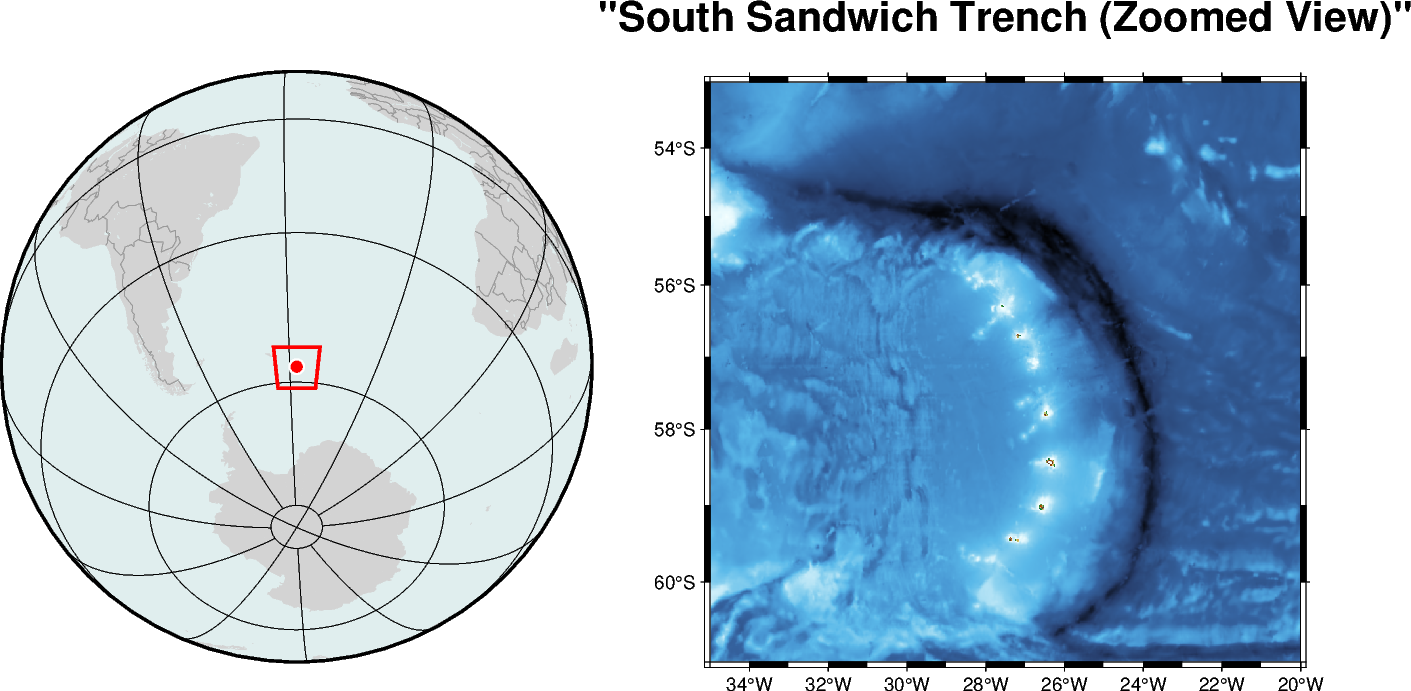

In [ ]:
import pygmt
import numpy as np
from IPython.display import Image

# 1. 設定區域與中心點 (南桑威奇海溝)
lon_c, lat_c = -27.5, -57
region_zoom = [-35, -20, -61, -53]

fig = pygmt.Figure()

# ==================== A. 繪製左側 3D 立體地球 ====================
print("正在繪製立體地球...")
# 使用 G (Orthographic 正射投影) 打造 3D 旋轉地球視角
fig.coast(
    region="g",                         # 全球範圍
    projection=f"G{lon_c}/{lat_c}/10c",  # 以目標為中心的立體視角，寬度 10cm
    land="lightgray",
    water="azure2",
    borders="1/0.2p,gray60",
    frame="g30",                        # 繪製格線強化立體球體感
)

# 在立體地球上標示紅色目標區域框與紅點
box_x = [region_zoom[0], region_zoom[1], region_zoom[1], region_zoom[0], region_zoom[0]]
box_y = [region_zoom[2], region_zoom[2], region_zoom[3], region_zoom[3], region_zoom[2]]
fig.plot(x=box_x, y=box_y, pen="1.5p,red")
fig.plot(x=lon_c, y=lat_c, style="c0.25c", fill="red", pen="0.8p,white")

# ==================== B. 繪製右側高解析度放大圖 ====================
print("正在繪製放大區域圖...")
# 向右平移 12 公分開始繪製右圖
fig.shift_origin(xshift="12c")

# 下載放大區域的地形資料
grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_zoom)

# 繪製區域地形圖 (Mercator 投影)
fig.grdimage(
    grid=grid,
    region=region_zoom,
    projection="M10c",
    cmap="geo",
    frame=['a2f1', 'WSne+t"South Sandwich Trench (Zoomed View)"'],
)


# ==================== C. 儲存與顯示 ====================
OUT = "globe_zoom_sandwich_trench.png"
fig.savefig(OUT, dpi=150)
print("繪製完成！儲存於：", OUT)

# 在 Colab 畫面印出圖片
Image(OUT)# 1. 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# 2. 設定儲存至您指定的資料夾路徑
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)
out_file = os.path.join(folder_path, "global_sandwich1.png")

# 3. 儲存圖片至雲端硬碟並在畫面上顯示
fig.savefig(out_file, dpi=150)
print("圖片已成功儲存至雲端硬碟：", out_file)

Image(out_file)

正在從 USGS 下載 2000 年至今 M>=5.0 地震資料...


grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
grdblend [NOTICE]: SRTM15 Earth Relief v2.7 at 01x01 arc minutes reduced by Gaussian Cartesian filtering (5.2 km fullwidth) [Tozer et al., 2019].
grdblend [NOTICE]:   -> Download 30x30 degree grid tile (earth_relief_01m_g): S90W060


成功下載 1534 筆地震資料！
正在繪製地形底圖與詳細標牌...
正在繪製地震點...


colorbar [ERROR]: Cannot access custom file in -B string x-component 0,70,300,700
colorbar [ERROR]: Cannot access custom file in -B string x-component 0,70,300,700


正在繪製右上角立體地球...
本地繪製完成！儲存於： south_sandwich_seismicity_perfect.png


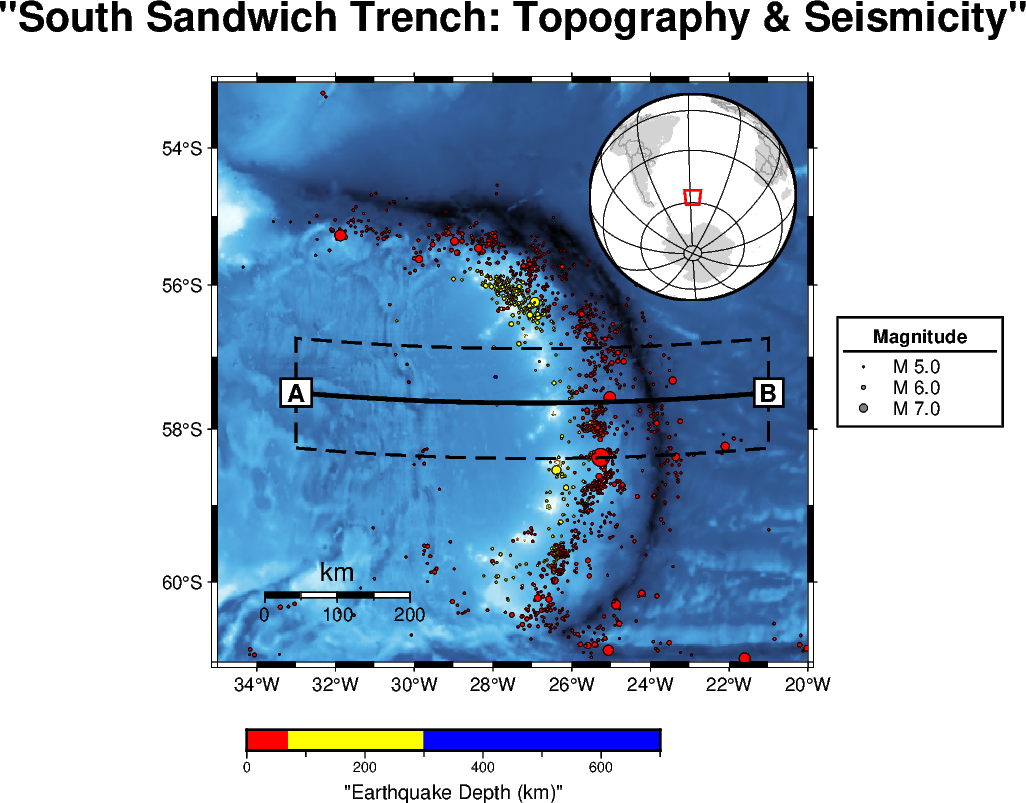

Mounted at /content/drive
圖片已成功儲存至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/global_sandwich2.png


In [ ]:
import os
import pandas as pd
import pygmt
import numpy as np
from IPython.display import Image
from google.colab import drive

# ==================== 1. 設定區域與參數 (南桑威奇海溝) ====================
region_zoom = [-35, -20, -61, -53]
lon_c, lat_c = -27.5, -57           # 立體地球視角中心

fig = pygmt.Figure()

# ==================== 2. 從 USGS 下載南桑威奇海溝地震資料 ====================
print("正在從 USGS 下載 2000 年至今 M>=5.0 地震資料...")
url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv"
    "&starttime=2000-01-01&minmagnitude=5.0"
    "&minlatitude=-61&maxlatitude=-53&minlongitude=-35&maxlongitude=-20"
)

try:
    df = pd.read_csv(url)
    print(f"成功下載 {len(df)} 筆地震資料！")

    if len(df) > 20000:
        print("資料量過大，自動調整規模門檻至 M >= 5.5")
        df = df[df["mag"] >= 5.5]

except Exception as e:
    print("⚠️ USGS API 抓取失敗，自動改用本地備用資料展示：", e)
    np.random.seed(42)
    n_points = 400
    df = pd.DataFrame({
        'longitude': np.random.uniform(-34, -21, n_points),
        'latitude': np.random.uniform(-60, -54, n_points),
        'depth': np.random.uniform(10, 650, n_points),
        'mag': np.random.uniform(5.0, 7.2, n_points)
    })

# ==================== 3. 繪製高解析度地形底圖與詳細標頭 ====================
print("正在繪製地形底圖與詳細標牌...")
grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_zoom)

# 繪製地形與詳細標頭名稱
fig.grdimage(
    grid=grid,
    region=region_zoom,
    projection="M10c",
    cmap="geo",
    frame=['a2f1', 'WSne+t"South Sandwich Trench: Topography & Seismicity"'],
)

# 新增左下角比例尺 (標示 200 km)
fig.basemap(
    region=region_zoom,
    projection="M10c",
    map_scale="jBL+w200k+o0.8c/1.0c+f+lkm",
)

# ==================== 4. 建立自訂三區間色階 (紅、黃、藍) ====================
print("正在繪製地震點...")

# 手動建立 GMT CPT 檔案：0-70km(紅)、70-300km(黃)、300-700km(藍)
cpt_content = """0	red	70	red
70	yellow	300	yellow
300	blue	700	blue
B	red
F	blue
N	gray
"""

with open("depth_3levels.cpt", "w") as f:
    f.write(cpt_content)

sizes = 0.025 * (2 ** (df["mag"] - 4.5))

fig.plot(
    x=df["longitude"].values,
    y=df["latitude"].values,
    fill=df["depth"].values,
    size=sizes.values,
    style="cc",
    cmap="depth_3levels.cpt",
    pen="0.2p,black",
)

# ==================== 5. 繪製 A-B 剖面線與帶虛線的取樣框 ====================
A_lon, A_lat = -33.0, -57.5
B_lon, B_lat = -21.0, -57.5

box_x = [A_lon, B_lon, B_lon, A_lon, A_lon]
box_y = [A_lat - 0.75, B_lat - 0.75, B_lat + 0.75, A_lat + 0.75, A_lat - 0.75]
fig.plot(x=box_x, y=box_y, pen="1.2p,black,-")
fig.plot(x=[A_lon, B_lon], y=[A_lat, B_lat], pen="2p,black")

fig.text(
    x=A_lon, y=A_lat, text="A",
    font="12p,Helvetica-Bold,black",
    justify="CM",
    fill="white", pen="1p,black", clearance="0.12c/0.08c"
)

fig.text(
    x=B_lon, y=B_lat, text="B",
    font="12p,Helvetica-Bold,black",
    justify="CM",
    fill="white", pen="1p,black", clearance="0.12c/0.08c"
)

# ==================== 6. 下方橫軸：地震深度顏色條 (Colorbar) ====================
# 標示 0, 70, 300, 700 km 分界刻度
fig.colorbar(
    cmap="depth_3levels.cpt",
    position="jBL+w7c/0.35c+h+o0.5c/-1.5c",
    frame=['pxc0,70,300,700', 'x+l"Earthquake Depth (km)"'],
)

# ==================== 6.5. 使用原生 Legend 畫在「地圖外側右邊」 ====================
s_m5 = 0.025 * (2 ** (5.0 - 4.5))
s_m6 = 0.025 * (2 ** (6.0 - 4.5))
s_m7 = 0.025 * (2 ** (7.0 - 4.5))

legend_txt = f"""H 9p,Helvetica-Bold Magnitude
D 0.1c 1p
S 0.3c c {s_m5}c gray50 0.2p,black 0.8c M 5.0
S 0.3c c {s_m6}c gray50 0.2p,black 0.8c M 6.0
S 0.3c c {s_m7}c gray50 0.2p,black 0.8c M 7.0
"""

with open("mag_legend.txt", "w") as f:
    f.write(legend_txt)

fig.legend(
    spec="mag_legend.txt",
    position="JMR+jML+o0.5c/0c+w2.8c",
    box="+gwhite+p0.8p,black"
)

# ==================== 7. 繪製右上角 3D 立體地球 (Inset) ====================
print("正在繪製右上角立體地球...")
with fig.inset(position="jTR+w3.5c+o0.2c/0.2c", margin=0):
    fig.coast(
        region="g",
        projection=f"G{lon_c}/{lat_c}/3.5c",
        land="lightgray",
        water="white",
        borders="1/0.2p,gray60",
        frame="g30",
    )
    box_x = [-35, -20, -20, -35, -35]
    box_y = [-61, -61, -53, -53, -61]
    fig.plot(x=box_x, y=box_y, pen="1p,red")

# ==================== 8. 儲存圖片與 Google Drive 備份 ====================
local_out = "south_sandwich_seismicity_perfect.png"
fig.savefig(local_out, dpi=150)
print("本地繪製完成！儲存於：", local_out)

display(Image(local_out))

# 掛載 Google 雲端硬碟並備份
drive.mount('/content/drive', force_remount=True)
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)
drive_out = os.path.join(folder_path, "global_sandwich2.png")

fig.savefig(drive_out, dpi=150)
print("圖片已成功儲存至雲端硬碟：", drive_out)

2. 地形與地震分佈（Topography & Seismicity）
海底地形剖面 (A-B Profile)：剖面 A 到 B：顯示南美板塊（或大西洋板塊）向西俯衝至南桑威奇微板塊之下。   
海溝深度：在剖面約 540 公里處達到最深，海溝深度超過 -7,500 公尺（約 8,000 公尺深）。

  地震活動與和達-班尼奧夫帶（Wadati-Benioff Zone）：
    淺層地震：震源深度 < 70 公里（紅點），集中在海溝附近及火山弧下方。   
    中深層地震：隨著向西移動（A點方向），地震深度逐漸加深（黃色為 70–300 公里，藍色為 > 300 公里）。   
    俯衝角度：剖面圖中的地震點排列成一條向西傾斜的帶狀結構，清晰展現了俯衝板塊進入地函的傾斜角度與軌跡。

正在從 USGS 下載全局地震資料...
成功下載 1534 筆地震資料！
正在繪製 圖一：平面地圖...
正在繪製 圖二：剖面圖...

繪製完成！正在顯示並備份圖片...


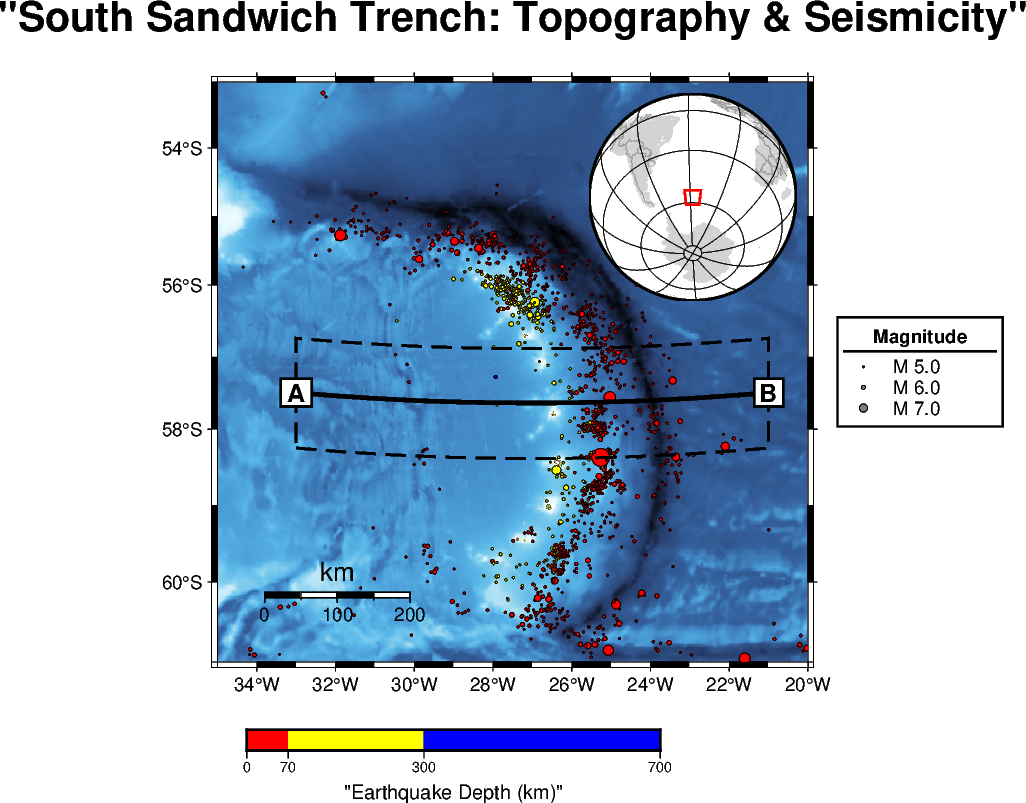

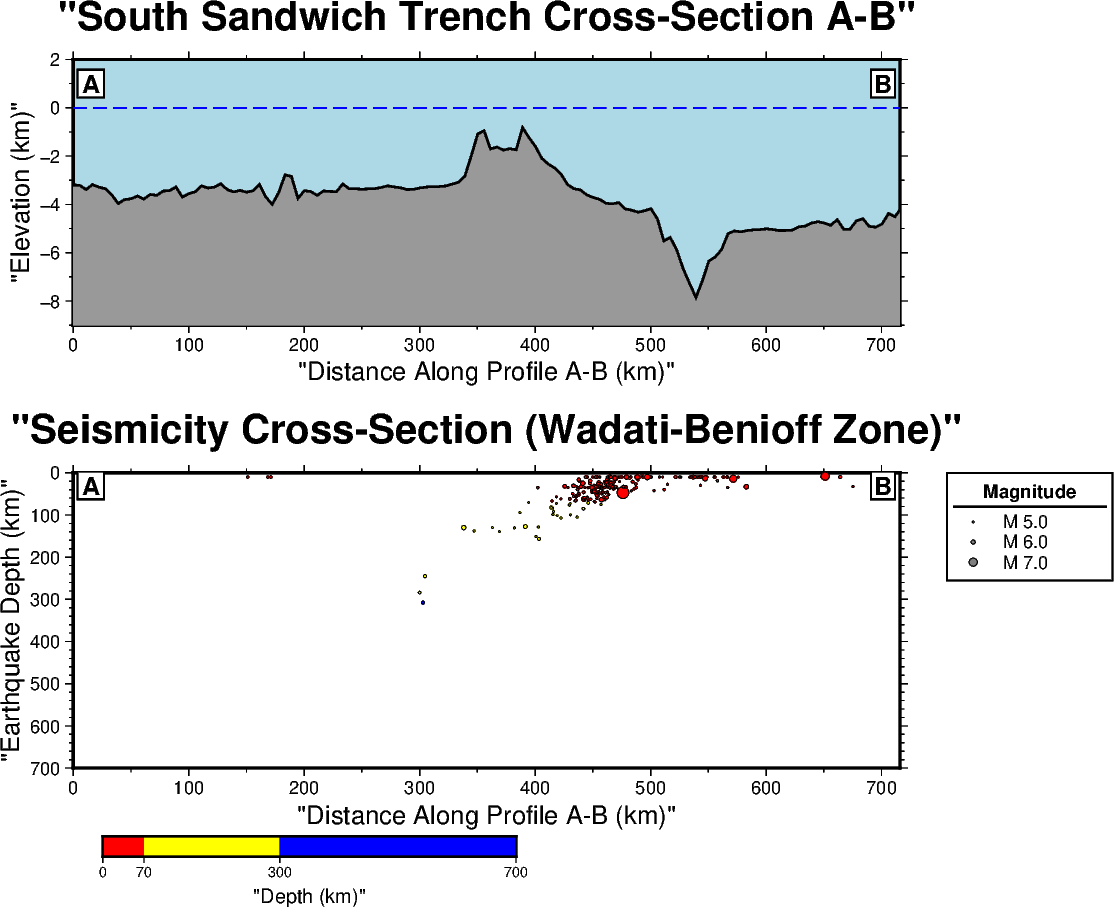

Mounted at /content/drive
兩張圖均已成功備份至雲端硬碟！


In [ ]:
import os
import pandas as pd
import pygmt
import numpy as np
from IPython.display import Image
from google.colab import drive

# ==================== 0. 全局共用參數設定 ====================
region_zoom = [-35, -20, -61, -53]  # 地圖範圍
lon_c, lat_c = -27.5, -57           # 立體地球視角中心

A_lon, A_lat = -33.0, -57.5          # 剖面起點 A
B_lon, B_lat = -21.0, -57.5          # 剖面終點 B
width_deg = 0.75                    # 剖面取樣走廊半寬度 (度)

# 1. 建立全局共用 3 區間 CPT 檔 (0-70km: 紅, 70-300km: 黃, 300-700km: 藍)
cpt_file = "depth_3levels.cpt"
cpt_content = """0	red	70	red
70	yellow	300	yellow
300	blue	700	blue
B	red
F	blue
N	gray
"""
with open(cpt_file, "w") as f:
    f.write(cpt_content)

# 2. 建立自訂深度 Colorbar 的刻度與標籤描述檔 (明確標示 0, 70, 300, 700)
custom_ticks_file = "depth_ticks.txt"
with open(custom_ticks_file, "w") as f:
    f.write("0 a 0\n70 a 70\n300 a 300\n700 a 700\n")

# ==================== 1. 統一下載 USGS 地震資料 ====================
print("正在從 USGS 下載全局地震資料...")
url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv"
    "&starttime=2000-01-01&minmagnitude=5.0"
    "&minlatitude=-61&maxlatitude=-53&minlongitude=-35&maxlongitude=-20"
)

try:
    df = pd.read_csv(url)
    print(f"成功下載 {len(df)} 筆地震資料！")
    if len(df) > 20000:
        df = df[df["mag"] >= 5.5]
except Exception as e:
    print("⚠️ USGS API 抓取失敗，自動改用本地備用資料展示：", e)
    np.random.seed(42)
    n_points = 500
    lons = np.random.uniform(-34, -21, n_points)
    depths = (lons - (-21)) * (-20) + np.random.normal(0, 15, n_points)
    depths = np.clip(depths, 10, 650)
    df = pd.DataFrame({
        'longitude': lons,
        'latitude': np.random.uniform(-60, -54, n_points),
        'depth': depths,
        'mag': np.random.uniform(5.0, 7.2, n_points)
    })

# 載入地形網格
grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region_zoom)


# ==============================================================================
# 圖一：平面地圖 (Topography & Seismicity Map)
# ==============================================================================
print("正在繪製 圖一：平面地圖...")
fig1 = pygmt.Figure()

# 繪製地形底圖
fig1.grdimage(
    grid=grid,
    region=region_zoom,
    projection="M10c",
    cmap="geo",
    frame=['a2f1', 'WSne+t"South Sandwich Trench: Topography & Seismicity"'],
)

# 比例尺
fig1.basemap(
    region=region_zoom,
    projection="M10c",
    map_scale="jBL+w200k+o0.8c/1.0c+f+lkm",
)

# 繪製地震點 (統一大小公式: 0.025 * 2^(mag - 4.5))
map_sizes = 0.025 * (2 ** (df["mag"] - 4.5))
fig1.plot(
    x=df["longitude"].values,
    y=df["latitude"].values,
    fill=df["depth"].values,
    size=map_sizes.values,
    style="cc",
    cmap=cpt_file,
    pen="0.2p,black",
)

# 繪製 A-B 剖面線與取樣框
box_x = [A_lon, B_lon, B_lon, A_lon, A_lon]
box_y = [A_lat - width_deg, B_lat - width_deg, B_lat + width_deg, A_lat + width_deg, A_lat - width_deg]
fig1.plot(x=box_x, y=box_y, pen="1.2p,black,-")
fig1.plot(x=[A_lon, B_lon], y=[A_lat, B_lat], pen="2p,black")

fig1.text(x=A_lon, y=A_lat, text="A", font="12p,Helvetica-Bold,black", justify="CM", fill="white", pen="1p,black", clearance="0.12c/0.08c")
fig1.text(x=B_lon, y=B_lat, text="B", font="12p,Helvetica-Bold,black", justify="CM", fill="white", pen="1p,black", clearance="0.12c/0.08c")

# 顏色條 (標示 0, 70, 300, 700 km)
fig1.colorbar(
    cmap=cpt_file,
    position="jBL+w7c/0.35c+h+o0.5c/-1.5c",
    frame=[f'c{custom_ticks_file}', 'x+l"Earthquake Depth (km)"'],
)

# 圖例 (外側右邊)
s_m5 = 0.025 * (2 ** (5.0 - 4.5))
s_m6 = 0.025 * (2 ** (6.0 - 4.5))
s_m7 = 0.025 * (2 ** (7.0 - 4.5))
legend_txt = f"""H 9p,Helvetica-Bold Magnitude
D 0.1c 1p
S 0.3c c {s_m5}c gray50 0.2p,black 0.8c M 5.0
S 0.3c c {s_m6}c gray50 0.2p,black 0.8c M 6.0
S 0.3c c {s_m7}c gray50 0.2p,black 0.8c M 7.0
"""
with open("mag_legend.txt", "w") as f:
    f.write(legend_txt)

fig1.legend(
    spec="mag_legend.txt",
    position="JMR+jML+o0.5c/0c+w2.8c",
    box="+gwhite+p0.8p,black"
)

# 右上角 3D 立體球
with fig1.inset(position="jTR+w3.5c+o0.2c/0.2c", margin=0):
    fig1.coast(
        region="g",
        projection=f"G{lon_c}/{lat_c}/3.5c",
        land="lightgray",
        water="white",
        borders="1/0.2p,gray60",
        frame="g30",
    )
    fig1.plot(x=[-35, -20, -20, -35, -35], y=[-61, -61, -53, -53, -61], pen="1p,red")

out_map = "south_sandwich_seismicity_perfect.png"
fig1.savefig(out_map, dpi=150)


# ==============================================================================
# 圖二：剖面圖 (Cross-Section Profile)
# ==============================================================================
print("正在繪製 圖二：剖面圖...")
fig2 = pygmt.Figure()

# 計算沿線地形
track = pygmt.project(center=[A_lon, A_lat], endpoint=[B_lon, B_lat], generate=0.05)
track_topo = pygmt.grdtrack(grid=grid, points=track, newcolname="z")

deg_to_km = 111.195
x_topo = track_topo["p"].values * deg_to_km
y_topo_km = track_topo["z"].values / 1000.0
max_dist = float(x_topo.max())

fill_x = np.concatenate([[0], x_topo, [max_dist, 0]])
fill_y = np.concatenate([[-10], y_topo_km, [-10, -10]])

# 篩選走廊內的地震點（精準計算沿線距離）
in_corridor = (df['latitude'] >= A_lat - width_deg) & (df['latitude'] <= A_lat + width_deg)
df_corr = df[in_corridor].copy()

deg_lon_to_km = deg_to_km * np.cos(np.radians(A_lat))
eq_p = (df_corr['longitude'].values - A_lon) * deg_lon_to_km
eq_depth = df_corr['depth'].values
# 使用與圖一完全一致的點大小公式
eq_sizes = 0.025 * (2 ** (df_corr['mag'].values - 4.5))

# --- 上半部：地形剖面 ---
region_topo = [0, max_dist, -9, 2]
proj_topo = "X14c/4.5c"

fig2.basemap(
    region=region_topo,
    projection=proj_topo,
    frame=['xa100f50+l"Distance Along Profile A-B (km)"',
           'ya2f1+l"Elevation (km)"',
           'WSne+t"South Sandwich Trench Cross-Section A-B"+glightblue']
)
fig2.plot(x=fill_x, y=fill_y, region=region_topo, projection=proj_topo, fill="gray60")
fig2.plot(x=x_topo, y=y_topo_km, region=region_topo, projection=proj_topo, pen="1p,black")
fig2.plot(x=[0, max_dist], y=[0, 0], region=region_topo, projection=proj_topo, pen="0.8p,blue,--")

fig2.text(x=15, y=1.0, text="A", font="12p,Helvetica-Bold,black", justify="CM", fill="white", pen="0.8p,black", clearance="0.08c")
fig2.text(x=max_dist-15, y=1.0, text="B", font="12p,Helvetica-Bold,black", justify="CM", fill="white", pen="0.8p,black", clearance="0.08c")

# --- 下半部：地震震源剖面 ---
fig2.shift_origin(yshift="-7.5c")
region_eq = [0, max_dist, 0, 700]
proj_eq = "X14c/-5.0c"

fig2.basemap(
    region=region_eq,
    projection=proj_eq,
    frame=['xa100f50+l"Distance Along Profile A-B (km)"',
           'ya100f20+l"Earthquake Depth (km)"',
           'WSne+t"Seismicity Cross-Section (Wadati-Benioff Zone)"']
)

fig2.plot(
    x=eq_p,
    y=eq_depth,
    region=region_eq,
    projection=proj_eq,
    fill=eq_depth,
    size=eq_sizes,
    style="cc",
    cmap=cpt_file,
    pen="0.2p,black",
)

fig2.text(x=15, y=30, text="A", font="12p,Helvetica-Bold,black", justify="CM", fill="white", pen="0.8p,black", clearance="0.08c")
fig2.text(x=max_dist-15, y=30, text="B", font="12p,Helvetica-Bold,black", justify="CM", fill="white", pen="0.8p,black", clearance="0.08c")

# 下方 Colorbar (標示 0, 70, 300, 700 km)
fig2.colorbar(
    cmap=cpt_file,
    position="jBL+w7c/0.35c+h+o0.5c/-1.5c",
    frame=[f'c{custom_ticks_file}', 'x+l"Depth (km)"'],
)

# 【關鍵修正】：右側 Magnitude 圖例 (改用 JTR+jTL 相對圖形右上角定位，不需 shift_origin)
fig2.legend(
    spec="mag_legend.txt",
    position="JTR+jTL+o0.8c/0c+w2.8c",
    box="+gwhite+p0.8p,black"
)

out_section = "south_sandwich_outside_legend.png"
fig2.savefig(out_section, dpi=150)


# ==================== 8. 顯示圖片與備份至 Google Drive ====================
print("\n繪製完成！正在顯示並備份圖片...")
display(Image(out_map))
display(Image(out_section))

drive.mount('/content/drive', force_remount=True)
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)

fig1.savefig(os.path.join(folder_path, "global_sandwich2.png"), dpi=150)
fig2.savefig(os.path.join(folder_path, "global_sandwich3.png"), dpi=150)

print("兩張圖均已成功備份至雲端硬碟！")

3.地震波速度異常與板塊剖面（dvp TX2019slab Cross-Section）   地震波震波速度（dvp %）：藍色（Fast）：代表地震波傳播速度較快（正異常），對應於高密度、低溫的冷俯衝板塊（Subducted Slab）。圖中可看到一塊高速度異常體延伸至地下 200–300 公里深處。   紅色/棕色（Slow）：代表震波速度較慢（負異常），對應於地函熱物質或較高溫度的環境。   與地震分佈疊加：地震活動（上方紅點/黑點）精準地落在震波速度較快的冷板塊上方及頂部邊界，證明了俯衝板塊的物理性質與幾何結構。

1/4 正在抓取 USGS 地震數據...
成功取得 1534 筆 USGS 地震數據！
南桑威奇海溝 profile 總長 716.0 km，走廊內共 169 筆地震
3/4 進行 3D 速度模型剖面插值...
4/4 正在繪製速度剖面圖...


/usr/local/lib/python3.13/site-packages/pygmt/clib/session.py:1647: RuntimeWarning:

Grid may have irregular spacing in the 'x' dimension, but GMT only supports regular spacing. Calculated regular spacing 9.944552924346578 is assumed in the 'x' dimension.



本地繪製完成！儲存於： tomography_section.png
Mounted at /content/drive
圖片已成功儲存至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/sandwich4.png


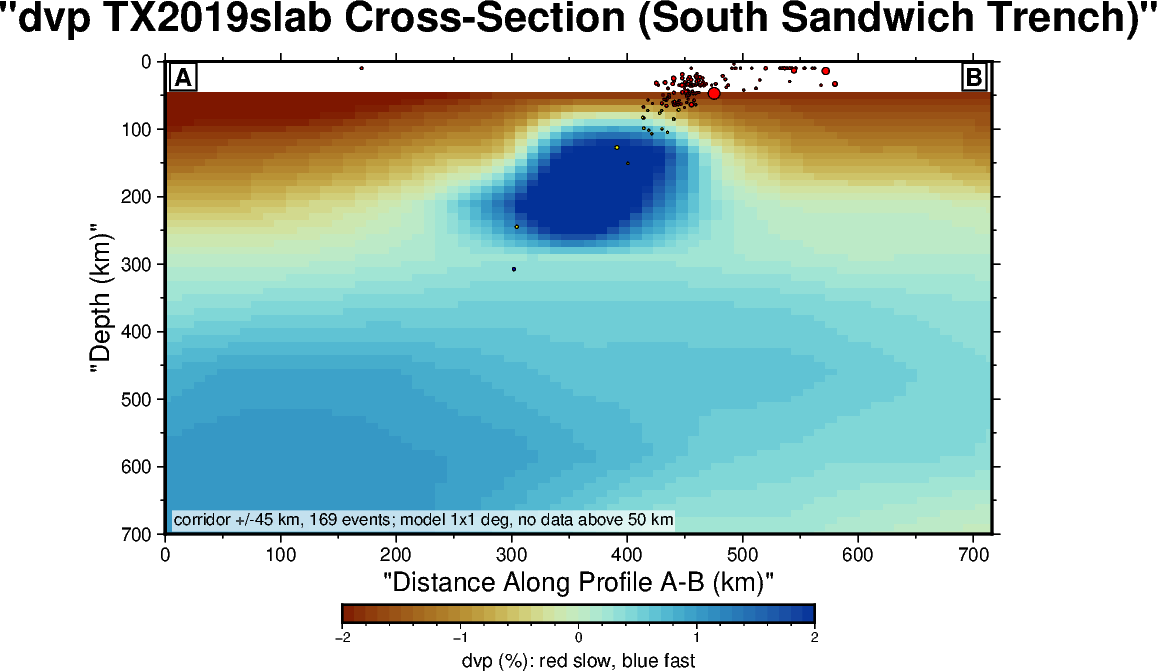

In [ ]:
"""
速度剖面：同一條 A–B 底下鋪 TX2019slab（Lu et al. 2019）的 P 波速度異常，地震疊在上面。
輸出：tomography_section.png
資料：EarthScope EMC TX2019slab、USGS 地震目錄 API（與南桑威奇海溝地圖完全同步）
"""
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import pygmt
import xarray as xr
from pygmt.clib import Session
from IPython.display import Image
from google.colab import drive

# ==================== 1. 設定區域與參數 (南桑威奇海溝) ====================
REGION = [-35, -20, -61, -53]
START, MINMAG = "2000-01-01", 5.0
A, B = (-33.0, -57.5), (-21.0, -57.5)

# 0.75度緯度轉換為公里數：0.75 * 111.195 * cos(-57.5 deg) ≈ 45 km
HALF_WIDTH_KM = 45
DEPTH_MAX = 700
VAR = "dvp"                         # 或 "dvs"
MODEL = "TX2019slab.nc"
MODEL_URL = "https://data.earthscope.org/archive/seismology/products/emc/netcdf/TX2019slab_percent.r0.0-n4c.nc"
OUT = "tomography_section.png"
# ==========================================================================

# 1. 下載/讀取與前面 100% 一致的 USGS 地震數據
print("1/4 正在抓取 USGS 地震數據...")
base = "https://earthquake.usgs.gov/fdsnws/event/1/"
query = (f"starttime={START}&minmagnitude={MINMAG}"
         f"&minlongitude={REGION[0]}&maxlongitude={REGION[1]}&minlatitude={REGION[2]}&maxlatitude={REGION[3]}")

try:
    quakes = pd.read_csv(base + "query?format=csv&" + query).dropna(subset=["longitude", "latitude", "depth", "mag"])
    print(f"成功取得 {len(quakes)} 筆 USGS 地震數據！")
except Exception as e:
    print("⚠️ USGS API 擷取失敗，改用備用數據：", e)
    np.random.seed(42)
    n = 500
    lons = np.random.uniform(-34, -21, n)
    depths = (lons - (-21)) * (-20) + np.random.normal(0, 15, n)
    depths = np.clip(depths, 10, 650)
    quakes = pd.DataFrame({
        'longitude': lons,
        'latitude': np.random.uniform(-60, -54, n),
        'depth': depths,
        'mag': np.random.uniform(5.0, 7.2, n)
    })

# 計算走廊內的地震投影
selected = pygmt.project(data=quakes[["longitude", "latitude", "depth", "mag"]],
                         center=list(A), endpoint=list(B), unit=True, length="w",
                         width=[-HALF_WIDTH_KM, HALF_WIDTH_KM], convention="xypqz")
selected.columns = ["longitude", "latitude", "distance", "offset", "depth", "mag"]

track = pygmt.project(center=list(A), endpoint=list(B), generate=10, unit=True)
track.columns = ["lon", "lat", "distance"]
length_km = float(track.distance.iloc[-1])
print(f"南桑威奇海溝 profile 總長 {length_km:.1f} km，走廊內共 {len(selected)} 筆地震")


# 2. 下載 TX2019slab 速度模型（只下載一次）
if not os.path.exists(MODEL):
    print("2/4 下載 TX2019slab 速度模型...")
    urllib.request.urlretrieve(MODEL_URL, MODEL)

# 3. GMT 讀取 3D 震波速度模型並做沿線切片
print("3/4 進行 3D 速度模型剖面插值...")
info = pygmt.grdinfo(f"{MODEL}?{VAR}")
levels = [float(v) for v in re.search(r"z_levels: (.*)", info).group(1).split(",")]
levels = [level for level in levels if level <= DEPTH_MAX]

def sample_level(level):
    with Session() as lib:
        with lib.virtualfile_out(kind="grid") as vout:
            lib.call_module("grdinterpolate", [f"{MODEL}?{VAR}", f"-T{level}", f"-G{vout}"])
            layer = lib.virtualfile_to_raster(vfname=vout, kind="grid")
    return pygmt.grdtrack(points=track[["lon", "lat"]], grid=layer, newcolname="value").value.to_numpy()

matrix = np.array([sample_level(level) for level in levels])
levels = np.array(levels)

# 深度再內插成每 10 km (50 km 以下才有資料)
depths = np.arange(0, DEPTH_MAX + 10, 10)
slice_values = np.full((len(depths), matrix.shape[1]), np.nan)
for j in range(matrix.shape[1]):
    slice_values[:, j] = np.interp(depths, levels, matrix[:, j], left=np.nan, right=np.nan)
tomo = xr.DataArray(slice_values, coords={"y": depths, "x": track.distance.values}, dims=("y", "x"))


# 4. 繪製 Tomography 速度剖面圖 + 地震疊加
print("4/4 正在繪製速度剖面圖...")
fig = pygmt.Figure()

# 建立 3 區間深度色階檔 (0-70: 紅, 70-300: 黃, 300-700: 藍) 確保地震點顏色與前圖一致
cpt_file = "depth_3levels.cpt"
cpt_content = """0	red	70	red
70	yellow	300	yellow
300	blue	700	blue
B	red
F	blue
N	gray
"""
with open(cpt_file, "w") as f:
    f.write(cpt_content)

# 背景：Tomography 速度異常 (-2% 到 +2%)
pygmt.makecpt(cmap="roma", series=[-2, 2, 0.1])  # 紅慢、藍快
fig.grdimage(
    grid=tomo,
    region=[0, length_km, 0, DEPTH_MAX],
    projection="X14c/-8c",
    cmap=True,
    nan_transparent=True,
    frame=[f"WSne+t\"{VAR} TX2019slab Cross-Section (South Sandwich Trench)\"",
           "xa100f50+l\"Distance Along Profile A-B (km)\"",
           "ya100f50+l\"Depth (km)\""]
)

# 下方：速度 Colorbar
fig.colorbar(position="JBC+w8c/0.3c+h+o0c/1.2c", frame=["a1", f"+l{VAR} (%): red slow, blue fast"])

# 前景：疊加地震點（採用與前面完全一致的點大小公式：0.025 * 2^(mag - 4.5)）
eq_sizes = 0.025 * (2 ** (selected.mag - 4.5))

fig.plot(
    x=selected.distance,
    y=selected.depth,
    size=eq_sizes,
    fill=selected.depth,
    cmap=cpt_file,
    style="cc",
    pen="0.3p,black"
)


# 標註 A / B 端點
fig.text(text="A", position="TL", offset="0.15c/-0.1c", font="12p,Helvetica-Bold", fill="white", pen="0.8p,black", clearance="0.08c")
fig.text(text="B", position="TR", offset="-0.15c/-0.1c", font="12p,Helvetica-Bold", fill="white", pen="0.8p,black", clearance="0.08c")
fig.text(text=f"corridor +/-{HALF_WIDTH_KM} km, {len(selected)} events; model 1x1 deg, no data above 50 km",
         position="BL", offset="0.15c/0.15c", font="8p", fill="white@30")

fig.savefig(OUT, dpi=150)
print("本地繪製完成！儲存於：", OUT)


# ==================== 5. 掛載 Google Drive 並備份 ====================
drive.mount('/content/drive', force_remount=True)
folder_path = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(folder_path, exist_ok=True)
out_file = os.path.join(folder_path, "sandwich4.png")

fig.savefig(out_file, dpi=150)
print("圖片已成功儲存至雲端硬碟：", out_file)

display(Image(out_file))

4. 3D 海底地形多角度視覺化展示了南桑威奇海溝的三維地形模型，從西南（SW）、東側剖面（East Slice）、南側軸線（South Axis）、西側火山弧（West Arc）及北側高仰角（North Angle）等多個角度觀察。  
 突顯了深海溝與平行排列的火山島弧之間劇烈的高度落差。

In [ ]:
import pygmt
import numpy as np
import plotly.graph_objects as go

# ==================== 1. 設定區域 (南桑威奇海溝) ====================
REGION = [-35, -20, -61, -53]

print("1/2 正在下載高解析度海洋地形數據 (Earth Relief Grid)...")
# 下載 1 分角高解析度地形，並適度降採樣 (coarsen) 以利網頁 3D 流暢渲染
grid = pygmt.datasets.load_earth_relief(resolution="01m", region=REGION)
grid_coarse = grid.coarsen(lon=2, lat=2, boundary="trim").mean()

topo_lon = grid_coarse.lon.values
topo_lat = grid_coarse.lat.values
topo_z = grid_coarse.values / 1000.0  # 轉為公里 (km)
topo_x, topo_y = np.meshgrid(topo_lon, topo_lat)

# ==================== 2. 繪製 3D 海洋地形曲面 ====================
print("2/2 建立 3D 海洋地形模型...")

fig = go.Figure()

# 繪製海底地形 3D 曲面
fig.add_trace(go.Surface(
    x=topo_x,
    y=topo_y,
    z=topo_z,
    colorscale='Blues_r',      # 深海藍色配色，色彩越深代表海溝越深
    cmin=-8.5, cmax=1.0,
    colorbar=dict(
        title="Depth (km)",
        len=0.75,
        x=0.9
    ),
    name='Bathymetry'
))

# 視角控制與座標軸設定
fig.update_layout(
    title="3D Ocean Bathymetry (South Sandwich Trench)",
    autosize=True,
    width=980,
    height=750,
    scene=dict(
        xaxis=dict(title='Longitude', range=[-35, -20]),
        yaxis=dict(title='Latitude', range=[-61, -53]),
        zaxis=dict(title='Depth (km)', range=[-9, 2]),
        aspectratio=dict(x=1.2, y=1, z=0.5),  # 高度適度拉高，突出海溝下陷特徵
        camera=dict(
            eye=dict(x=-1.5, y=-1.5, z=0.9)   # 預設視角：從西南側俯瞰
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# 顯示 3D 互動圖表（滑鼠拖曳旋轉、滾輪縮放）
fig.show()

Output hidden; open in https://colab.research.google.com to view.

1/3 下載與準備地形資料...
2/3 正在渲染 6 個獨立 3D 靜態視角 (邊框修復，絕不重疊)...
3/3 乾淨 6 視角地貌圖繪製完成！儲存於： sandwich_6views_clean.png
Mounted at /content/drive
圖片已成功備份至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/sandwich_6views_clean.png


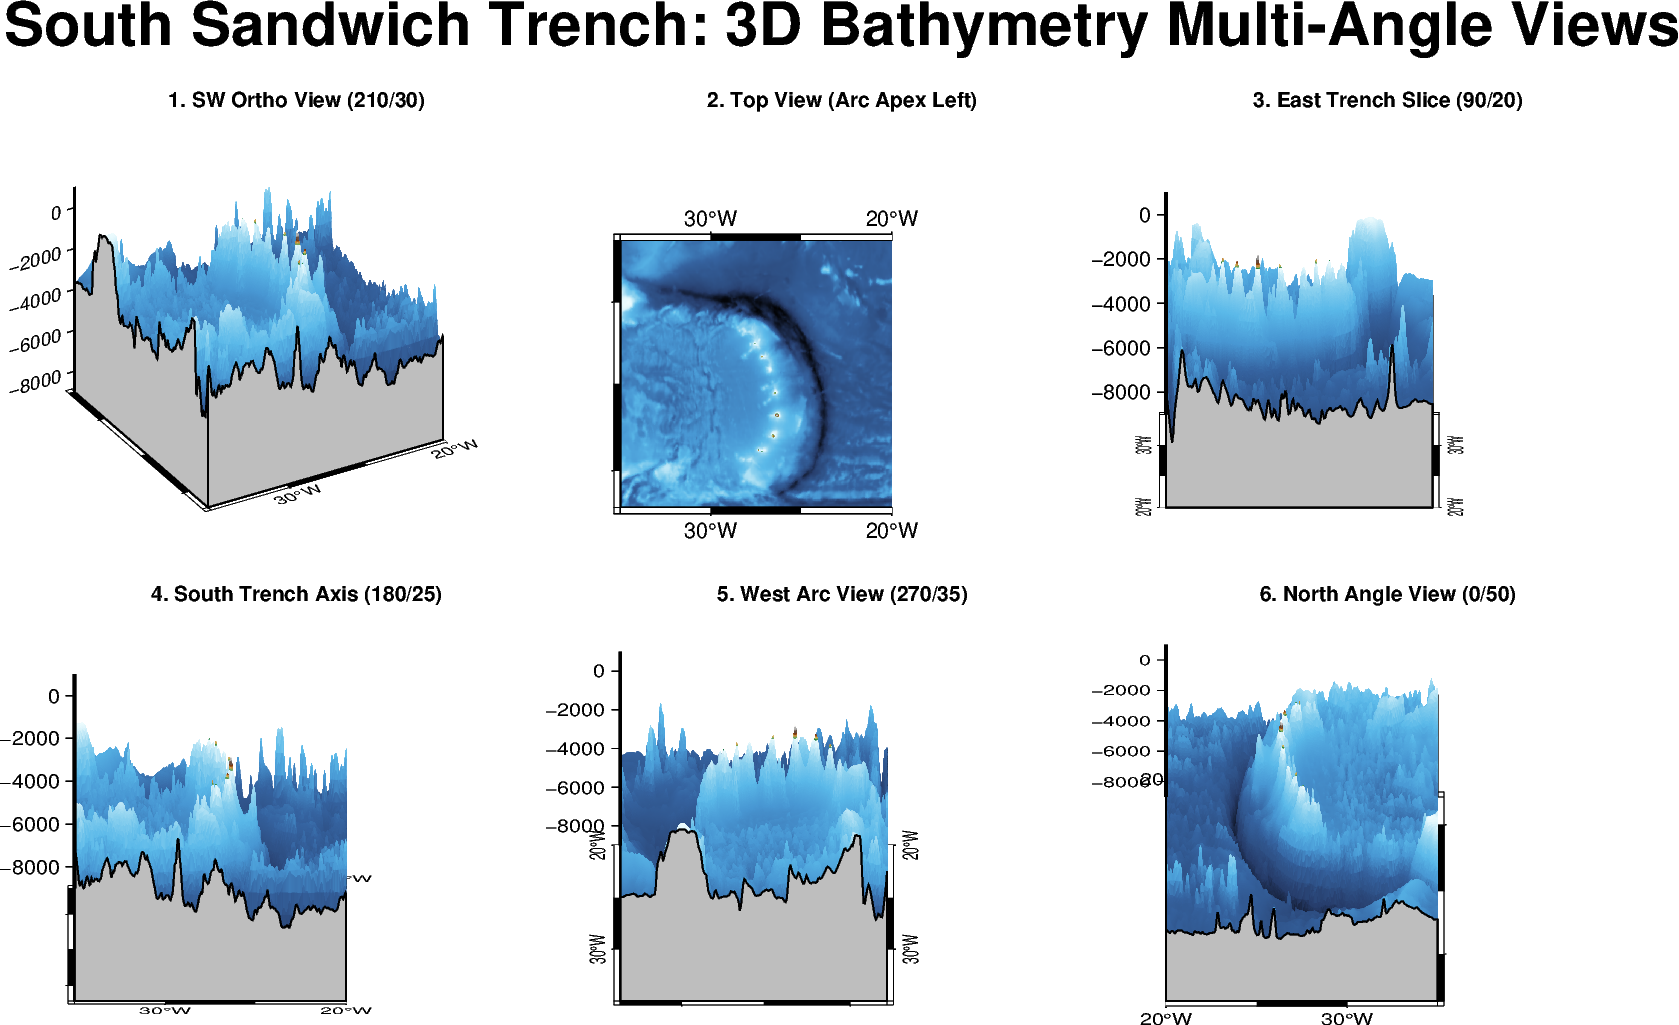

In [ ]:
import os
import pygmt
import pandas as pd
from google.colab import drive
from IPython.display import Image

# ==================== 1. 全局參數設定 ====================
REGION = [-35, -20, -61, -53]
OUT = "sandwich_6views_clean.png"

print("1/3 下載與準備地形資料...")
grid = pygmt.datasets.load_earth_relief(resolution="02m", region=REGION)

# 定義 6 個視角 (View 2 設為 [180, 90]，使海溝弓形尖尖朝左)
views = [
    {"title": "1. SW Ortho View (210/30)", "persp": [210, 30]},
    {"title": "2. Top View (Arc Apex Left)", "persp": [180, 90]}, # 弧尖朝左
    {"title": "3. East Trench Slice (90/20)", "persp": [90, 20]},
    {"title": "4. South Trench Axis (180/25)", "persp": [180, 25]},
    {"title": "5. West Arc View (270/35)", "persp": [270, 35]},
    {"title": "6. North Angle View (0/50)", "persp": [0, 50]}
]

# ==================== 2. 精確獨立 Subplot (乾淨邊框) ====================
print("2/3 正在渲染 6 個獨立 3D 靜態視角 (邊框修復，絕不重疊)...")

fig = pygmt.Figure()

# 使用標準繪圖邊界矩陣
with fig.subplot(
    nrows=2,
    ncols=3,
    figsize=("26c", "15c"),
    autolabel=False,
    margins=["0.6c", "0.6c"],   # 設定子圖邊距，乾淨隔離
    title="South Sandwich Trench: 3D Bathymetry Multi-Angle Views"
):
    for i, v in enumerate(views):
        with fig.set_panel(panel=i):
            # 直接在 grdview 繪製乾淨的 3D 邊框，取消外掛的 basemap 避免邊框變形
            fig.grdview(
                grid=grid,
                region=REGION + [-9000, 1000],
                projection="M4.6c",            # 小張圖，保持足夠安全距離
                zscale="0.0004c",              # 垂直立體高度
                perspective=v["persp"],
                cmap="geo",
                surftype="s",
                plane="-9000+ggray",
                frame=["x10f5", "y5f2.5", "z2000", "wSNZ"]  # 簡潔標準 3D 邊框
            )

            # 使用頂部文字標示子圖名稱，乾淨不壓圖
            fig.text(
                text=v["title"],
                position="TC",                 # 頂部中央 (Top Center)
                offset="0c/0.4c",              # 向上偏移，不與 3D 地形相撞
                font="10p,Helvetica-Bold,black",
                no_clip=True
            )

# 儲存靜態圖片
fig.savefig(OUT, dpi=150)
print("3/3 乾淨 6 視角地貌圖繪製完成！儲存於：", OUT)

# ==================== 3. 備份至 Google Drive 並顯示 ====================
try:
    drive.mount('/content/drive', force_remount=True)
    folder_path = "/content/drive/MyDrive/Colab Notebooks"
    os.makedirs(folder_path, exist_ok=True)
    out_file = os.path.join(folder_path, OUT)
    fig.savefig(out_file, dpi=150)
    print("圖片已成功備份至雲端硬碟：", out_file)
    display(Image(out_file))
except Exception as e:
    print("雲端硬碟備份跳過，顯示本地圖檔：")
    display(Image(OUT))

1/3 下載海洋地形數據 (Earth Relief Grid)...
2/3 渲染 3D 視角與右上角俯瞰縮圖 (清除雜訊標籤)...
3/3 乾淨無雜訊 3D 視角圖繪製完成！儲存於： sandwich_3d_clean_insets.png
Mounted at /content/drive
圖片已成功備份至雲端硬碟： /content/drive/MyDrive/Colab Notebooks/sandwich_3d_clean_insets.png


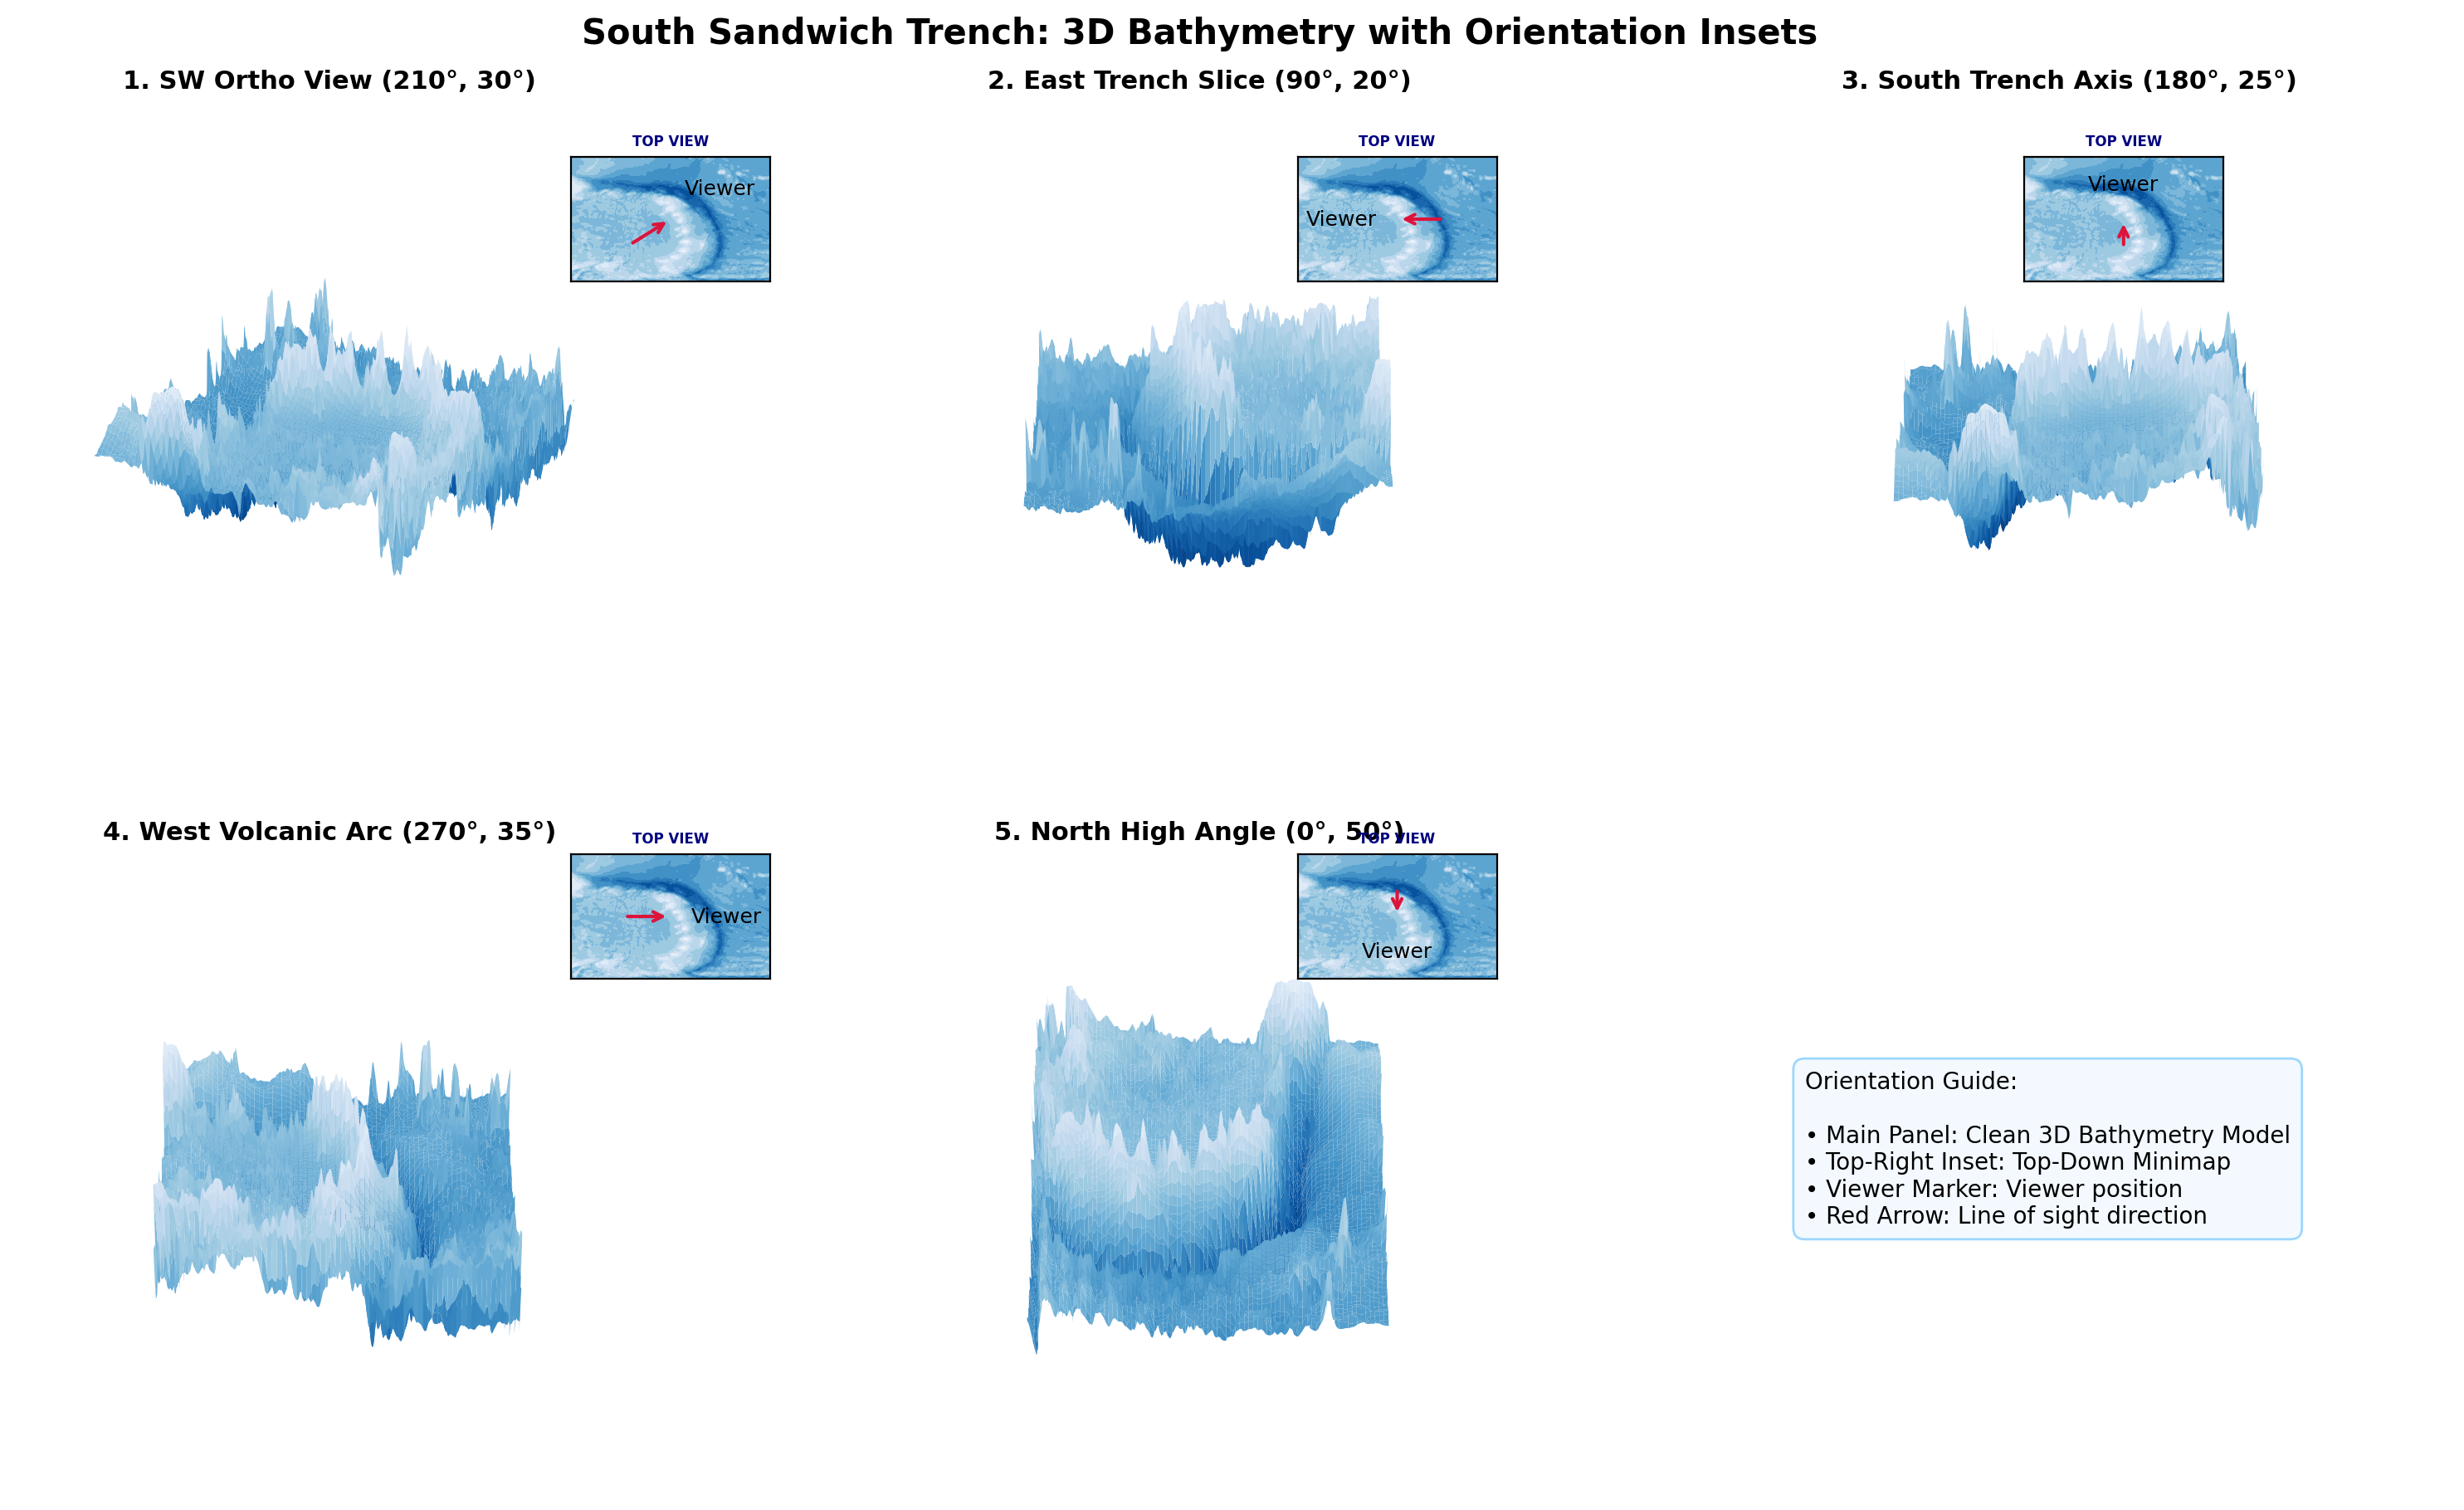

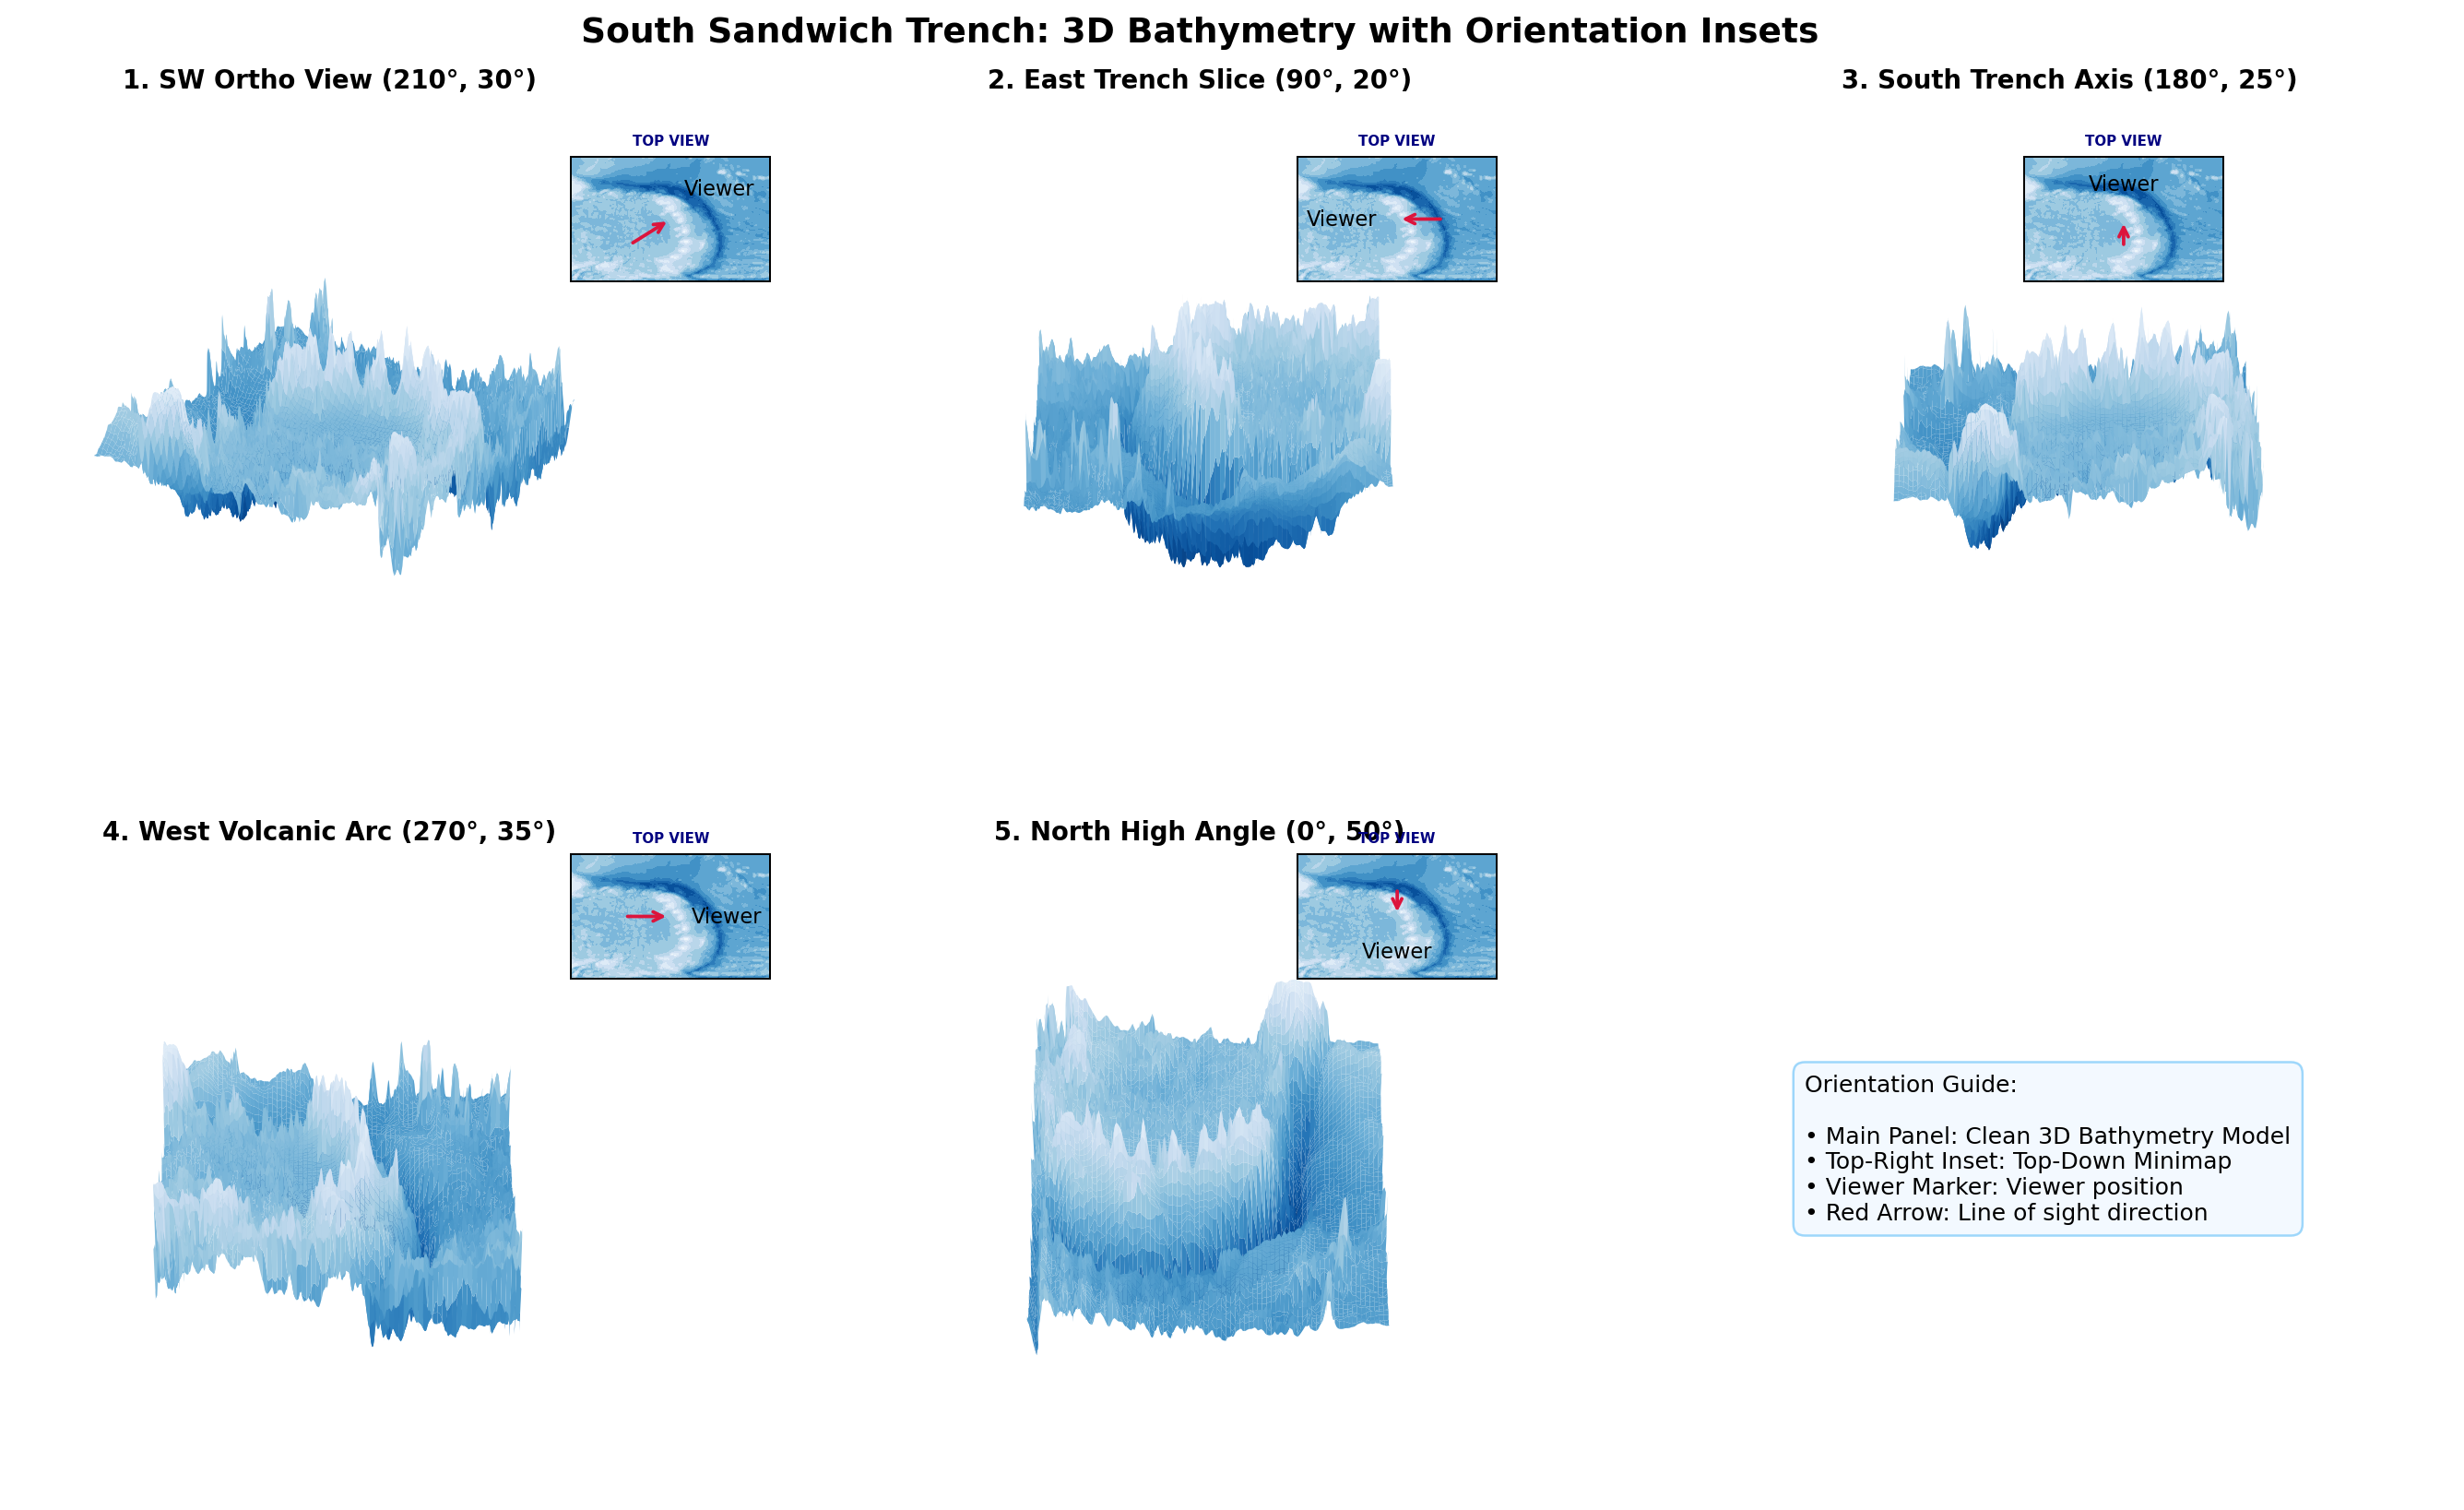

In [ ]:
import os
import pygmt
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import Image

# ==================== 1. 全局參數設定 ====================
REGION = [-35, -20, -61, -53]
OUT_FINAL = "sandwich_3d_clean_insets.png"

print("1/3 下載海洋地形數據 (Earth Relief Grid)...")
grid = pygmt.datasets.load_earth_relief(resolution="02m", region=REGION)

# 5 個精緻 3D 視角參數與視角位置向量
views = [
    {"title": "1. SW Ortho View (210°, 30°)", "azimuth": 210, "elevation": 30, "cam_x": -0.7, "cam_y": -0.7},
    {"title": "2. East Trench Slice (90°, 20°)", "azimuth": 90, "elevation": 20, "cam_x": 0.8, "cam_y": 0.0},
    {"title": "3. South Trench Axis (180°, 25°)", "azimuth": 180, "elevation": 25, "cam_x": 0.0, "cam_y": -0.8},
    {"title": "4. West Volcanic Arc (270°, 35°)", "azimuth": 270, "elevation": 35, "cam_x": -0.8, "cam_y": 0.0},
    {"title": "5. North High Angle (0°, 50°)", "azimuth": 0, "elevation": 50, "cam_x": 0.0, "cam_y": 0.8}
]

# ==================== 2. 構建高質感無重疊靜態畫布 ====================
print("2/3 渲染 3D 視角與右上角俯瞰縮圖 (清除雜訊標籤)...")

fig = plt.figure(figsize=(16, 10), dpi=180)
fig.suptitle("South Sandwich Trench: 3D Bathymetry with Orientation Insets", fontsize=15, fontweight='bold', y=0.94) # Adjusted y position

# 地形數據準備
topo_lon = grid.lon.values
topo_lat = grid.lat.values
topo_z = grid.values / 1000.0
x, y = np.meshgrid(topo_lon, topo_lat)

for idx, v in enumerate(views):
    # 使用預留邊距的 2x3 子圖佈局
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')

    # A. 繪製乾淨的 3D 地形本體
    surf = ax.plot_surface(
        x, y, topo_z,
        cmap='Blues_r',
        rcount=90, ccount=90,
        linewidth=0, antialiased=True,
        vmin=-8.5, vmax=1.0
    )

    # 設定 3D 視角與獨立標題
    ax.view_init(elev=v["elevation"], azim=v["azimuth"])
    ax.set_title(v["title"], fontsize=11, fontweight='bold', pad=12)
    ax.set_zlim(-9, 2)
    ax.axis('off')  # 關閉會扭曲的 3D 網格框

    # B. 精準定位右上角俯瞰導覽縮圖 (不與主地形重疊)
    pos = ax.get_position()
    # 將縮圖移至右上角安全空白處
    # 针对第5个面板（索引为4），进一步降低俯瞰图的y坐标
    if idx == 4: # Index 4 corresponds to the 5th panel
        inset_ax = fig.add_axes([pos.x1 - 0.085, pos.y1 - 0.12, 0.075, 0.075]) # Further adjusted y position for the 5th panel
    else:
        inset_ax = fig.add_axes([pos.x1 - 0.085, pos.y1 - 0.1, 0.075, 0.075])

    # 縮圖地形 (俯瞰圖，等高線填色)
    inset_ax.contourf(x, y, topo_z, levels=12, cmap='Blues_r', origin='lower')
    inset_ax.set_title("TOP VIEW", fontsize=6, fontweight='bold', color='navy', pad=5) # Adjusted pad
    inset_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 縮圖標註：視角小人 (🧍) 與紅色視角箭頭
    arrow_dx = -v["cam_x"] * 0.35
    arrow_dy = -v["cam_y"] * 0.35

    # 放置小人圖示
    inset_ax.annotate(
        "Viewer", xy=(0.5 + arrow_dx, 0.5 + arrow_dy), xycoords='axes fraction',
        fontsize=9, ha='center', va='center'
    )
    # 繪製指向中心的視角箭頭
    inset_ax.annotate(
        "", xy=(0.5, 0.5), xycoords='axes fraction',
        xytext=(0.5 + v["cam_x"]*0.3, 0.5 + v["cam_y"]*0.3), textcoords='axes fraction',
        arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5)
    )

# C. 第 6 格填入乾淨說明面板 (不含米字號雜訊)
ax_info = fig.add_subplot(2, 3, 6)
ax_info.axis('off')

info_text = (
    "Orientation Guide:\n\n"
    "• Main Panel: Clean 3D Bathymetry Model\n"
    "• Top-Right Inset: Top-Down Minimap\n"
    "• Viewer Marker: Viewer position\n" # Replaced emoji
    "• Red Arrow: Line of sight direction"
)

ax_info.text(
    0.15, 0.55, info_text,
    fontsize=10, fontfamily='sans-serif',
    transform=ax_info.transAxes, verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="aliceblue", edgecolor="lightskyblue", alpha=0.8)
)

# 調整子圖之間整體邊距，避免擁擠
plt.subplots_adjust(left=0.03, right=0.97, bottom=0.05, top=0.88, wspace=0.15, hspace=0.20) # Adjusted top margin

# 儲存高解析度圖片
plt.savefig(OUT_FINAL, dpi=200, bbox_inches='tight')
print("3/3 乾淨無雜訊 3D 視角圖繪製完成！儲存於：", OUT_FINAL)

# ==================== 3. 備份至 Google Drive 並顯示 ====================
try:
    drive.mount('/content/drive', force_remount=True)
    folder_path = "/content/drive/MyDrive/Colab Notebooks"
    os.makedirs(folder_path, exist_ok=True)
    out_file = os.path.join(folder_path, OUT_FINAL)
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    print("圖片已成功備份至雲端硬碟：", out_file)
    display(Image(out_file))
except Exception as e:
    print("雲端硬碟備份跳過，顯示本地圖檔：")
    display(Image(OUT_FINAL))

南桑威奇俯衝帶運動學：板塊運動向量（South Sandwich Subduction Kinematics: Plate Motion Vectors）。   主要構造與板塊：南美洲板塊（South America Plate）：位於北部與東側。   斯科舍板塊（Scotia Plate）：位於西側。   南桑威奇微板塊（South Sandwich Microplate）：位於海溝與弧後盆地之間。   聚合速率與運動：標註顯示相對聚合速率為每年 7～9 公分（7 ~ 9 cm/yr），圖中箭頭代表各板塊的運動方向向量。   地理範圍：涵蓋西經 $20^\circ\text{W} \sim 35^\circ\text{W}$、南緯 $50^\circ\text{S} \sim 60^\circ\text{S}$ 的南大西洋/南冰洋海域，下方附有 500 公里的比例尺。

南美洲板塊（South America Plate）向西俯衝至南桑威奇微板塊（South Sandwich Microplate）之下，兩者以每年約 7～9 公分 的相對速率相互擠壓與聚合。

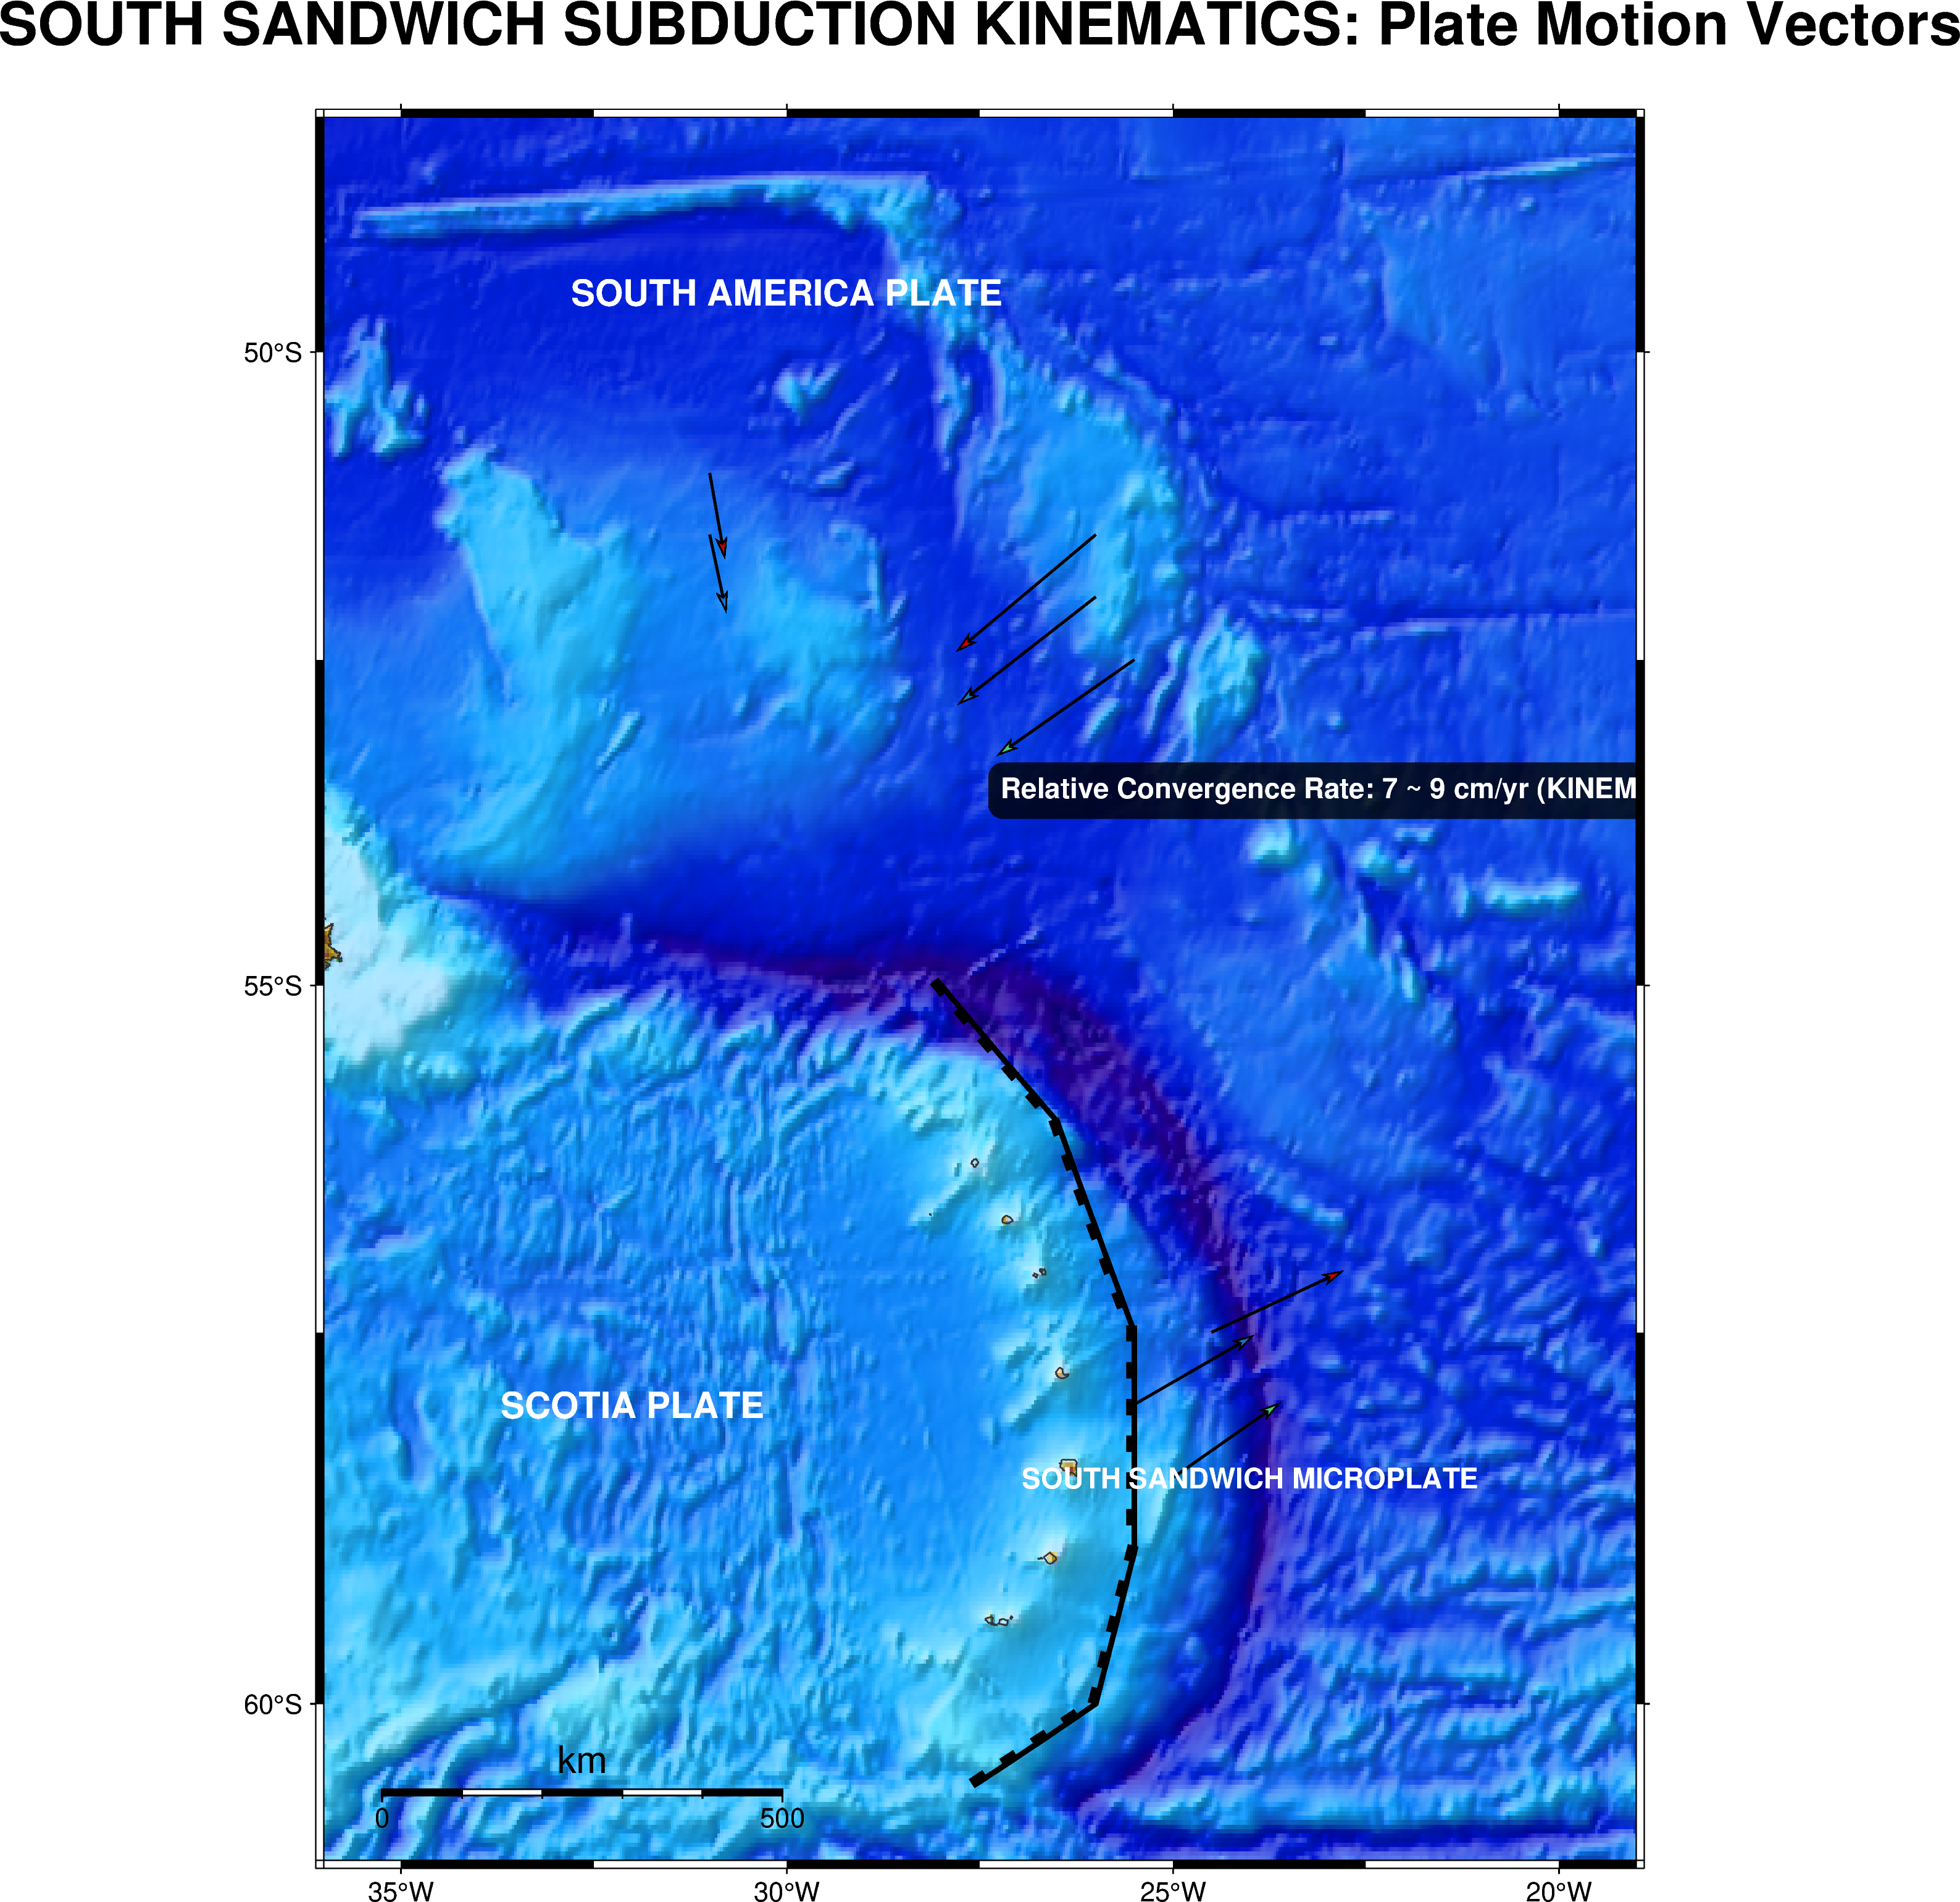

In [10]:
import pygmt
import pandas as pd

# 1. 設定區域與檔案名稱
region = [-36, -19, -61, -48]
projection = "M18c"  # 墨卡托投影，寬 18 cm
output_img = "south_sandwich_kinematics.png"

# 2. 準備向量數據 (x_lon, y_lat, angle, length_cm_yr)
# (A) GPS-derived 向量 (紅色)
gps_vectors = pd.DataFrame({
    'lon': [-31.0, -26.0, -24.5],
    'lat': [-51.0, -51.5, -57.5],
    'angle': [280, 220, 25],
    'length': [1.2, 2.5, 2.0]
})

# (B) MORVEL 向量 (藍色)
morvel_vectors = pd.DataFrame({
    'lon': [-31.0, -26.0, -25.5],
    'lat': [-51.5, -52.0, -58.0],
    'angle': [282, 218, 30],
    'length': [1.1, 2.4, 1.9]
})

# (C) NUVEL-1 向量 (綠色)
nuvel_vectors = pd.DataFrame({
    'lon': [-25.5, -25.0],
    'lat': [-52.5, -58.5],
    'angle': [215, 35],
    'length': [2.3, 1.8]
})

# 3. 初始化繪圖
fig = pygmt.Figure()

# 繪製高解析度海床與陸地地形底圖
fig.grdimage(
    grid="@earth_relief_02m",
    region=region,
    projection=projection,
    cmap="etopo1",
    shading="+a-45+nt0.5",
    frame=["a5f2.5", "+tSOUTH SANDWICH SUBDUCTION KINEMATICS: Plate Motion Vectors"]
)

# 補強海岸線
fig.coast(shorelines="0.5p,gray20", resolution="h")

# 4. 畫出南桑威奇海溝 (Subduction Zone / Trench)
trench_lon = [-28.0, -26.5, -25.5, -25.5, -26.0, -27.5]
trench_lat = [-55.0, -56.0, -57.5, -59.0, -60.0, -60.5]
fig.plot(
    x=trench_lon,
    y=trench_lat,
    pen="2p,black",
    style="f0.5c/0.15c+r+t+b"  # 隱沒帶齒狀圖樣
)

# 5. 繪製運動向量箭頭 (Velocities / Vectors)
# - GPS 向量 (紅色)
fig.plot(
    x=gps_vectors.lon,
    y=gps_vectors.lat,
    style="v0.3c+e",  # 修正：改用簡化的向量樣式 +e
    direction=[gps_vectors.angle, gps_vectors.length],
    fill="red3",
    pen="1p,black"
)

# - MORVEL 向量 (藍色)
fig.plot(
    x=morvel_vectors.lon,
    y=morvel_vectors.lat,
    style="v0.3c+e",  # 修正：改用簡化的向量樣式 +e
    direction=[morvel_vectors.angle, morvel_vectors.length],
    fill="dodgerblue3",
    pen="1p,black"
)

# - NUVEL-1 向量 (綠色)
fig.plot(
    x=nuvel_vectors.lon,
    y=nuvel_vectors.lat,
    style="v0.3c+e",  # 修正：改用簡化的向量樣式 +e
    direction=[nuvel_vectors.angle, nuvel_vectors.length],
    fill="seagreen3",
    pen="1p,black"
)
# 7. 標示板塊名稱與相對運動速度說明
fig.text(x=-30.0, y=-49.5, text="SOUTH AMERICA PLATE", font="14p,Helvetica-Bold,white")
fig.text(x=-32.0, y=-58.0, text="SCOTIA PLATE", font="14p,Helvetica-Bold,white")
fig.text(x=-24.0, y=-58.5, text="SOUTH SANDWICH\nMICROPLATE", font="11p,Helvetica-Bold,white")

# 標示運動學證明數據資訊框 (Kinematics relative convergence)
fig.text(
    x=-22.5,
    y=-53.5,
    text="Relative Convergence Rate:\n7 ~ 9 cm/yr (KINEMATICS)",
    font="11p,Helvetica-Bold,white",
    fill="black@20",
    clearance="0.2c+tO"
)

# 8. 圖例與比例尺
fig.basemap(
    map_scale="jBL+c-55/-30+w500k+l+f+o0.8c/0.8c"
)

# 儲存與顯示結果
fig.savefig(output_img, dpi=300)
fig.show()

南桑威奇俯衝：震源機制解

紅色位於中央、兩側為白色的圖案特徵，證實了該區地震多由水平擠壓造成的逆衝斷層活動所引發，直接印證了南美洲板塊向西俯衝時產生的強烈擠壓應力環境。

/tmp/ipykernel_1745/215467989.py:50: SyntaxWarning: Short-form parameter (E) is not recommended. Use long-form parameter 'extensionfill' instead.
  fig.meca(
/tmp/ipykernel_1745/215467989.py:50: SyntaxWarning: Short-form parameter (G) is not recommended. Use long-form parameter 'compressionfill' instead.
  fig.meca(
/tmp/ipykernel_1745/215467989.py:50: SyntaxWarning: Short-form parameter (W) is not recommended. Use long-form parameter 'pen' instead.
  fig.meca(


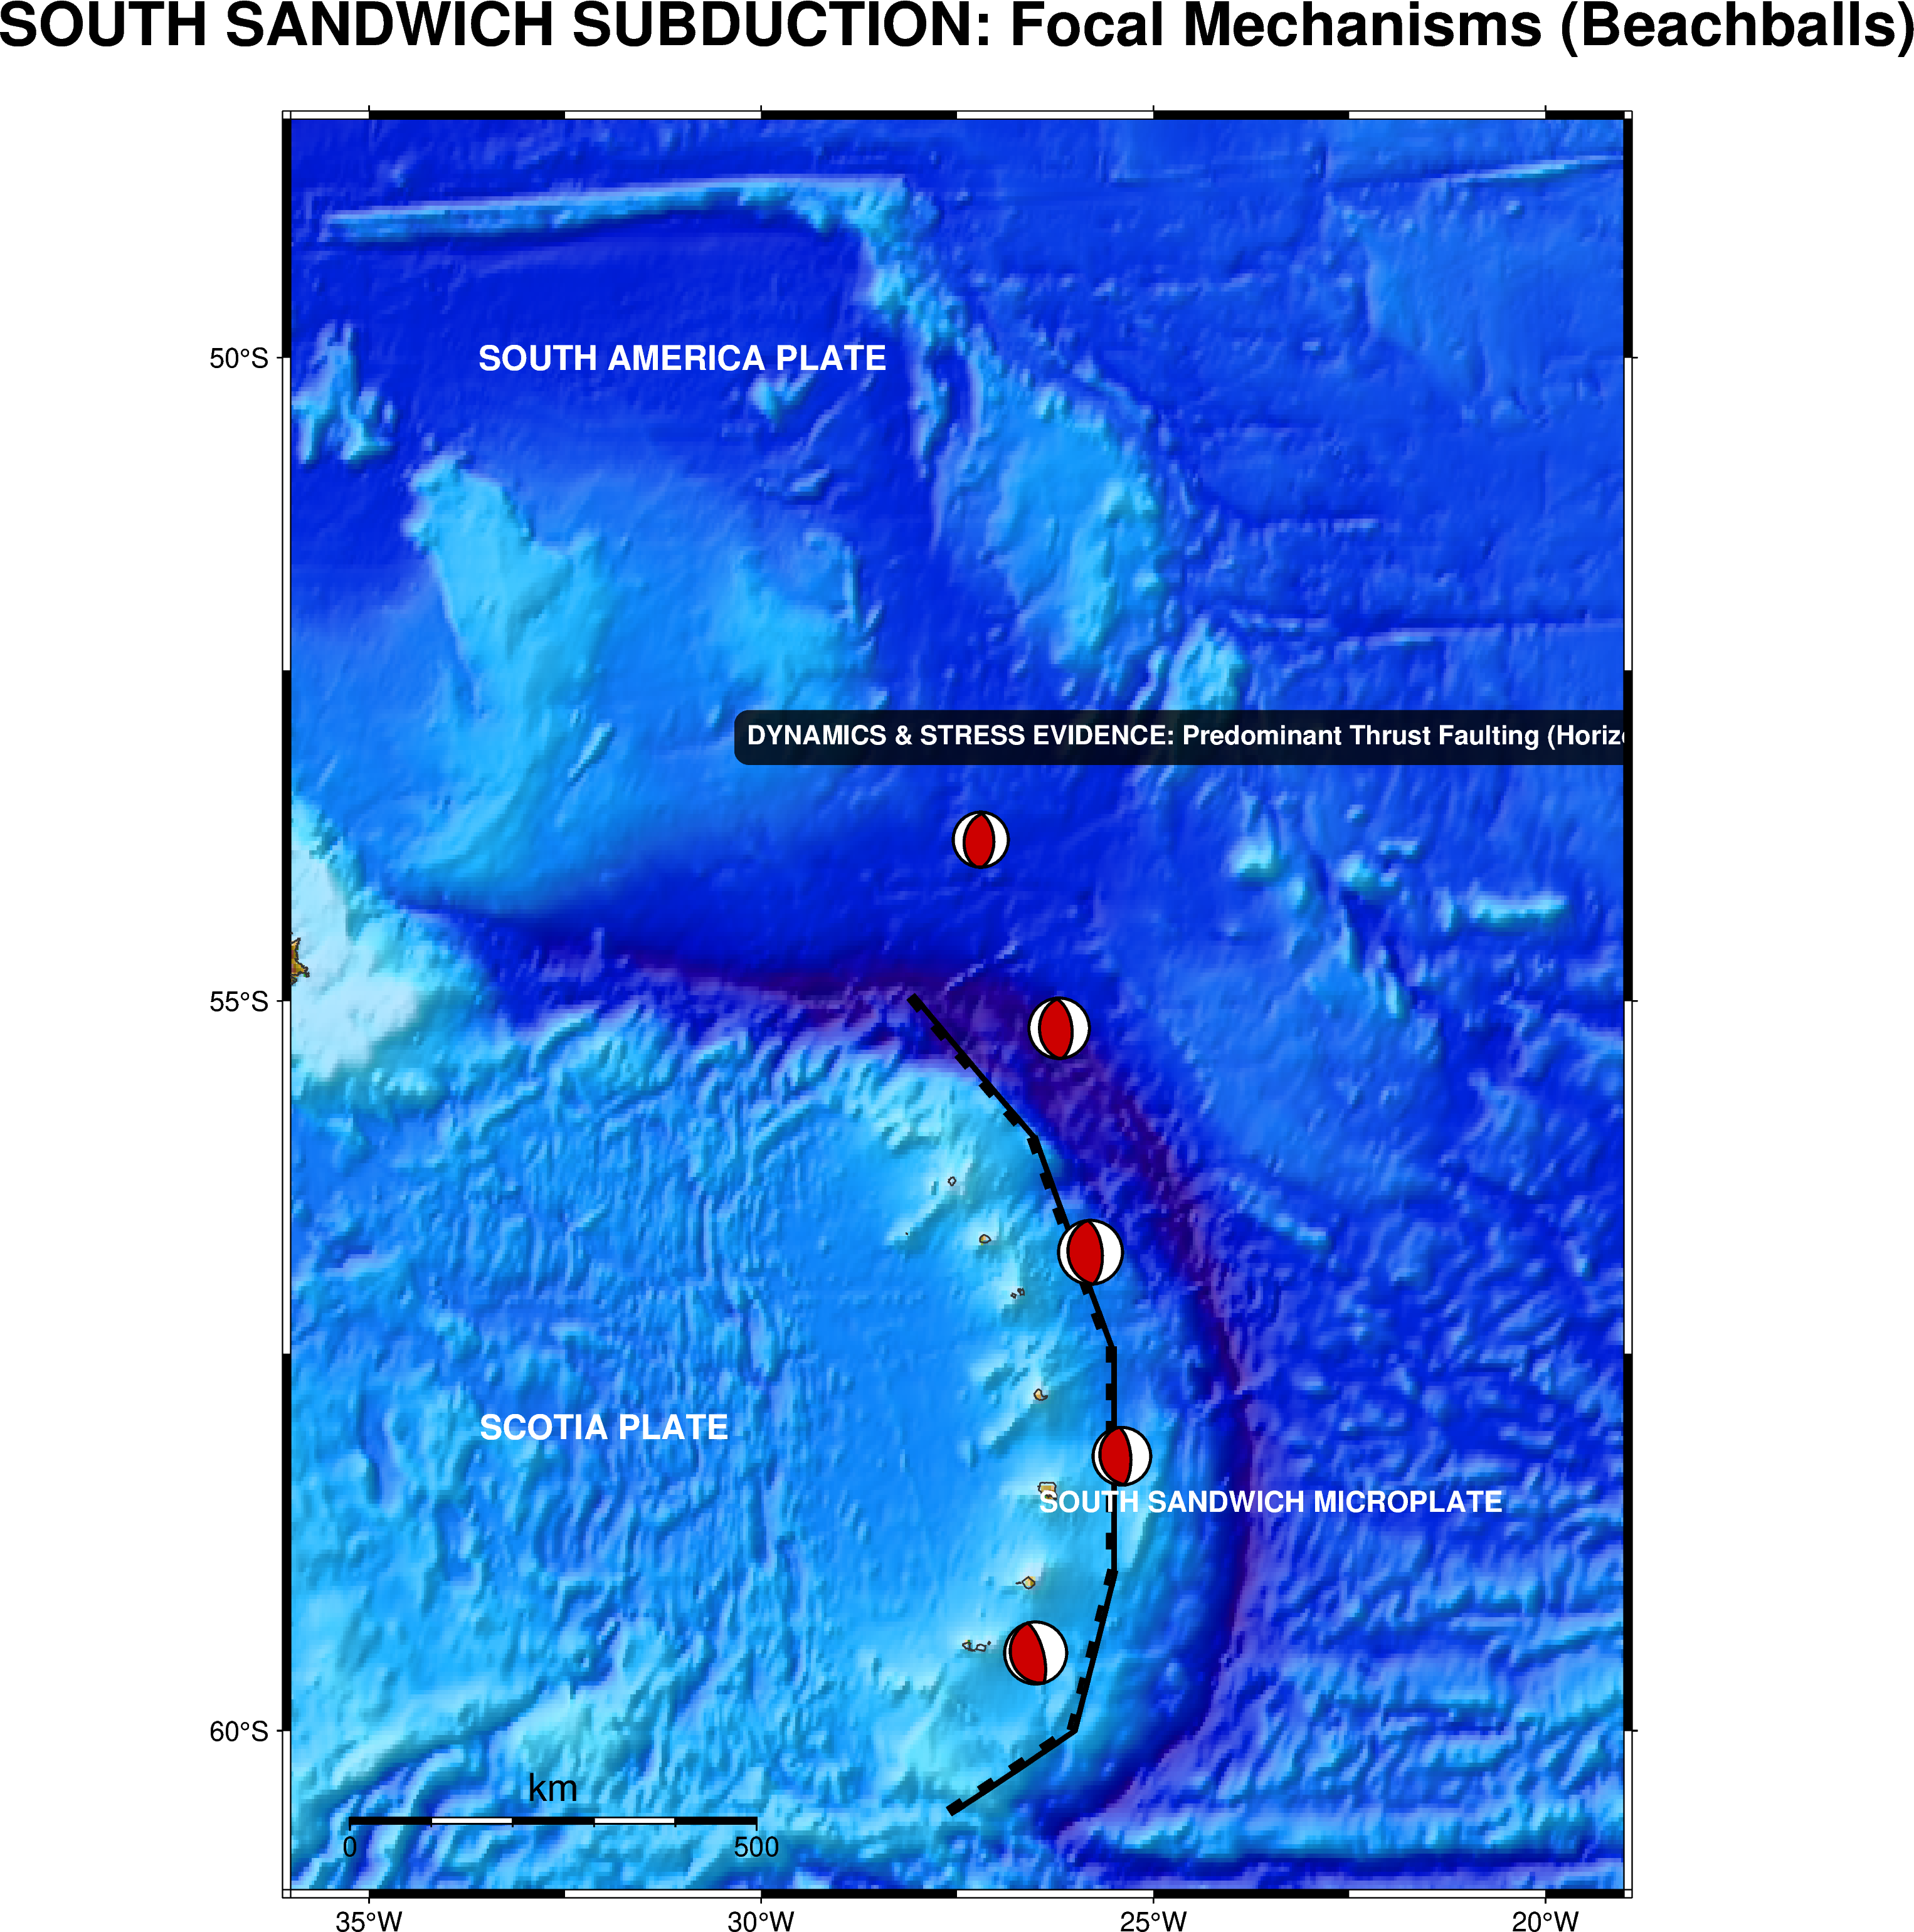

In [11]:
import pygmt
import pandas as pd

# 1. 設定繪圖區域與投影
region = [-36, -19, -61, -48]
projection = "M18c"  # 墨卡托投影，寬 18 cm
output_img = "south_sandwich_focal_mechanisms.png"

# 2. 準備震源機制解數據 (Focal Mechanism / Aki & Richards 格式: Strike, Dip, Rake, Mag)
# 逆衝斷層 (Thrust faulting): Rake 接近 90 度，顯示兩側受水平強烈擠壓
focal_data = pd.DataFrame({
    'longitude': [-26.2, -25.8, -25.4, -26.5, -27.2],
    'latitude':  [-55.2, -56.8, -58.2, -59.5, -53.8],
    'depth':     [  25.0,   32.0,   45.0,   50.0,   18.0],
    'strike':    [   180,    175,    170,    165,    190], # 斷層走向
    'dip':       [    35,     30,     25,     20,     40], # 傾角
    'rake':      [    95,     90,     85,     90,    100], # 斷層滑移角 (接近 90 為標準逆衝斷層)
    'magnitude': [   6.8,    7.2,    6.5,    7.0,    6.2], # 地震規模 (控制沙灘球大小)
    'title':     ["M6.8", "M7.2", "M6.5", "M7.0", "M6.2"]
})

# 3. 初始化繪圖
fig = pygmt.Figure()

# 繪製海床地形底圖
fig.grdimage(
    grid="@earth_relief_02m",
    region=region,
    projection=projection,
    cmap="etopo1",
    shading="+a-45+nt0.5",
    frame=["a5f2.5", "+tSOUTH SANDWICH SUBDUCTION: Focal Mechanisms (Beachballs)"]
)

# 補強海岸線
fig.coast(shorelines="0.5p,gray20", resolution="h")

# 4. 畫出南桑威奇海溝 (Subduction Trench)
trench_lon = [-28.0, -26.5, -25.5, -25.5, -26.0, -27.5]
trench_lat = [-55.0, -56.0, -57.5, -59.0, -60.0, -60.5]
fig.plot(
    x=trench_lon,
    y=trench_lat,
    pen="2p,black",
    style="f0.5c/0.15c+r+t+b"  # 隱沒帶齒狀圖樣 (指向俯衝方向)
)

# 5. 繪製震源機制解 (Beachballs)
# 使用 PyGMT meca 模組，Aki & Richards 格式 (spec=[strike, dip, rake, mag])
fig.meca(
    spec=focal_data,
    scale="0.6c",            # 控制沙灘球縮放大小
    convention="aki",        # 指定 Aki & Richards 震源參數規範
    G="red3",                # 壓縮區 (Compressional quadrant) 填色 (紅色)
    E="white",               # 張裂區 (Extensional quadrant) 填色 (白色)
    W="1p,black",            # 沙灘球邊框與節面線顏色線寬
    outline=True
)

# 6. 標示板塊名稱與應力證據說明框
fig.text(x=-31.0, y=-50.0, text="SOUTH AMERICA PLATE", font="13p,Helvetica-Bold,white")
fig.text(x=-32.0, y=-58.0, text="SCOTIA PLATE", font="13p,Helvetica-Bold,white")
fig.text(x=-23.5, y=-58.5, text="SOUTH SANDWICH\nMICROPLATE", font="11p,Helvetica-Bold,white")

# 應力與動力學證明文字框 (Dynamics & Stress)
fig.text(
    x=-22.5,
    y=-53.0,
    text="DYNAMICS & STRESS EVIDENCE:\nPredominant Thrust Faulting\n(Horizontal Compressive Stress)",
    font="10p,Helvetica-Bold,white",
    fill="black@20",
    clearance="0.2c+tO"
)

# 7. 圖例與比例尺
fig.basemap(
    map_scale="jBL+c-55/-30+w500k+l+f+o0.8c/0.8c"
)

# 儲存與顯示圖形
fig.savefig(output_img, dpi=300)
fig.show()

南桑威奇海床地殼地質年代與俯衝運動學

俯衝帶的南美洲板塊（South America Plate）地殼年代較老（圖中綠色至藍色區域，約 60–80 百萬年甚至更久），因密度大而自發性重力下沉俯衝。

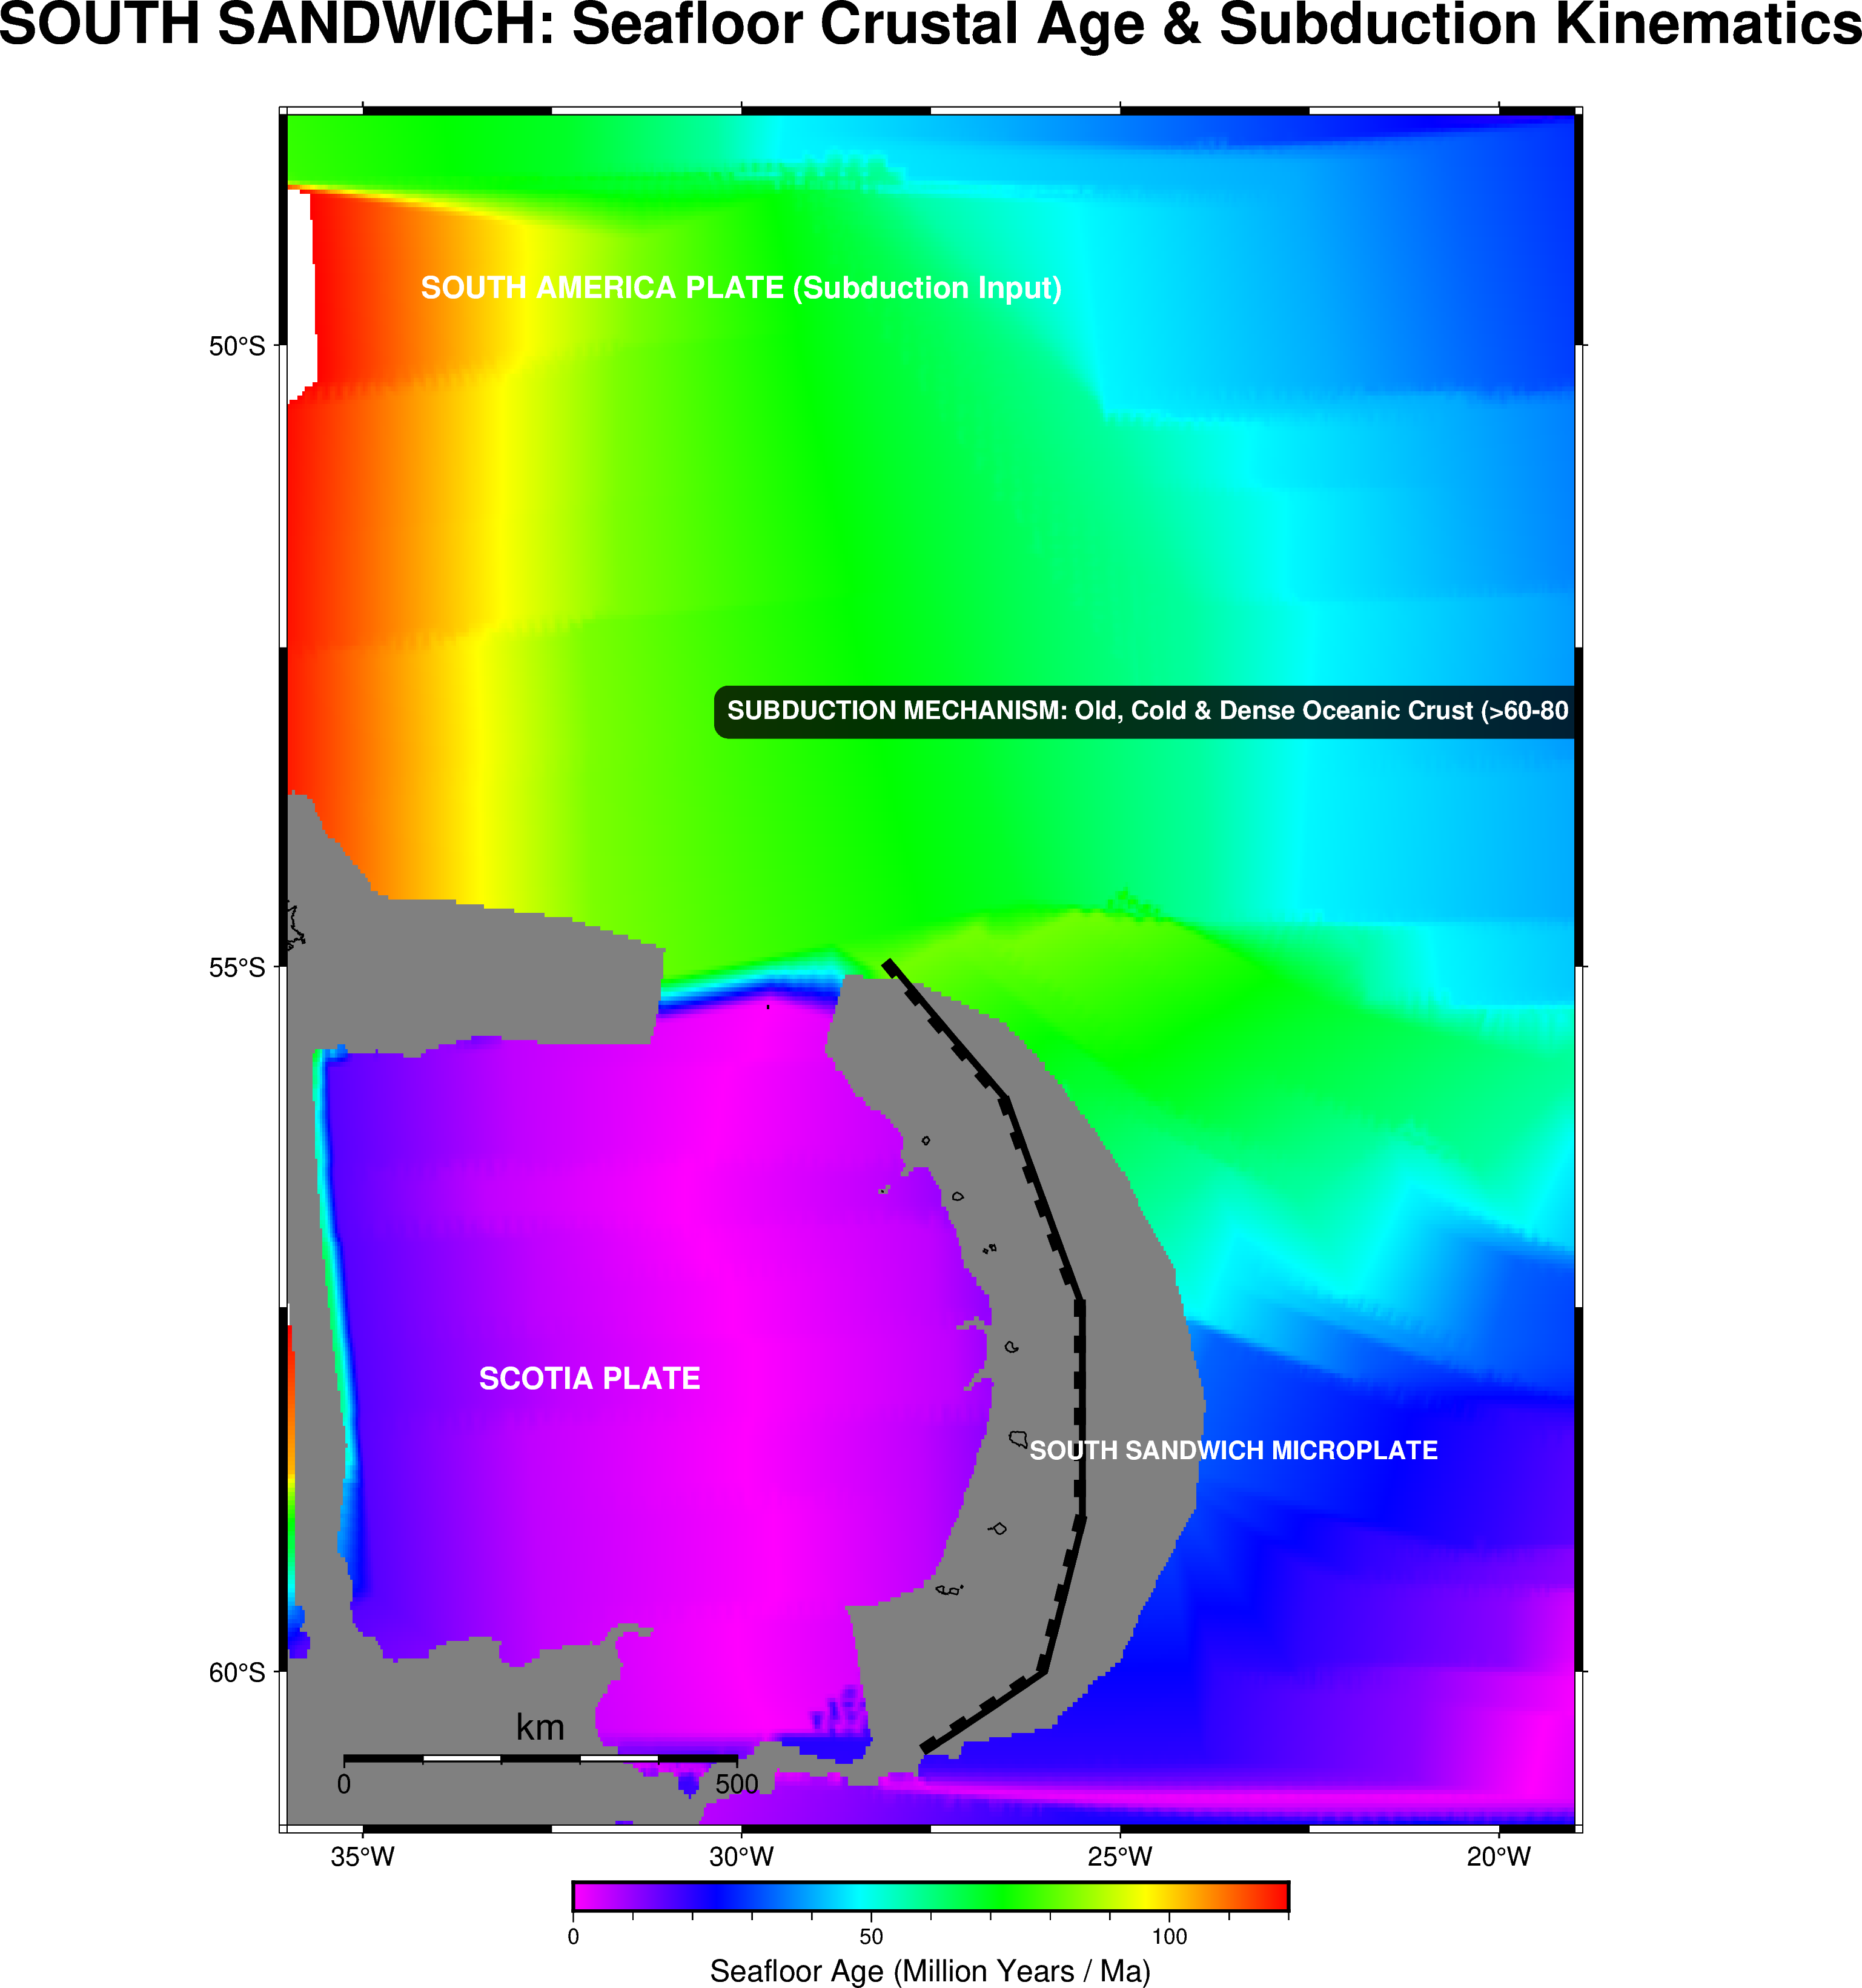

In [14]:
import pygmt

# 1. 設定繪圖區域與投影
region = [-36, -19, -61, -48]
projection = "M18c"  # 墨卡托投影，寬 18 cm
output_img = "seafloor_age_map.png"

# 2. 初始化 Figure
fig = pygmt.Figure()

# 3. 建立 CPT 色階表 (0 到 120 百萬年)
# 使用 GMT 內建的 "rainbow" 色階 (藍紫代表古老地殼，暖色/紅代表年輕地殼)
pygmt.makecpt(
    cmap="rainbow",
    series=[0, 120, 10],  # 範圍 0~120 Ma，每 10 Ma 一個刻度
    continuous=True
)

# 4. 繪製海底地殼年齡網格圖 (@earth_age_02m)
fig.grdimage(
    grid="@earth_age_02m",
    region=region,
    projection=projection,
    cmap=True,  # 套用上一步建立的 CPT
    frame=["a5f2.5", "+tSOUTH SANDWICH: Seafloor Crustal Age & Subduction Kinematics"]
)

# 5. 疊加海岸線
fig.coast(shorelines="0.5p,black", resolution="h")

# 6. 畫出南桑威奇海溝 (Subduction Zone / Trench)
trench_lon = [-28.0, -26.5, -25.5, -25.5, -26.0, -27.5]
trench_lat = [-55.0, -56.0, -57.5, -59.0, -60.0, -60.5]
fig.plot(
    x=trench_lon,
    y=trench_lat,
    pen="2.5p,black",
    style="f0.5c/0.15c+r+t+b"  # 隱沒帶齒狀圖樣 (指向俯衝方向)
)

# 7. 標示板塊名稱與密度/俯衝證明文字
fig.text(x=-30.0, y=-49.5, text="SOUTH AMERICA PLATE\n(Subduction Input)", font="12p,Helvetica-Bold,white")
fig.text(x=-32.0, y=-58.0, text="SCOTIA PLATE", font="12p,Helvetica-Bold,white")
fig.text(x=-23.5, y=-58.5, text="SOUTH SANDWICH\nMICROPLATE", font="10p,Helvetica-Bold,white")

# 物理機制證明標籤
fig.text(
    x=-22.5,
    y=-53.0,
    text="SUBDUCTION MECHANISM:\nOld, Cold & Dense Oceanic Crust\n(>60-80 Ma) Subducting Westward",
    font="10p,Helvetica-Bold,white",
    fill="black@20",
    clearance="0.2c+tO"
)

# 8. 繪製 Colorbar (色階尺)
fig.colorbar(
    position="JBC+w10c/0.4c+h+o0c/0.8c",
    frame=["a20f10", "+lSeafloor Age (Million Years / Ma)"]
)

# 9. 比例尺
fig.basemap(
    map_scale="jBL+c-55/-30+w500k+l+f+o0.8c/0.8c"
)

# 儲存與顯示結果
fig.savefig(output_img, dpi=300)
fig.show()